In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [92]:
df = pd.read_csv('app_performance_logs_with_labels(v3).csv')
df.head()

,timestamp,session_id,app_version,screen_name,api_latency_ms,ui_response_ms,fps,memory_mb,error_code,network_type,...,fps_zscore,memory_mb_rolling_mean_5,memory_mb_rolling_std_5,memory_mb_rolling_max_10,memory_mb_zscore,fps_change_rate,latency_change_rate,memory_growth_rate,recent_error_count,latency_cv
0,2026-02-21 09:02:33.224973,0100ff40-0782-4590-bdc0-7f2841c19e2c,1.2.0,profile,670,203,15,115.000000,0,wifi,...,0.000000,115.000000,0.000000,115.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,2026-02-21 09:02:38.224973,0100ff40-0782-4590-bdc0-7f2841c19e2c,1.2.0,search,463,248,26,133.685093,0,wifi,...,0.707107,124.342546,13.212356,133.685093,0.707107,0.733333,-0.308955,18.685093,0.0,0.258378
2,2026-02-21 09:02:44.224973,0100ff40-0782-4590-bdc0-7f2841c19e2c,1.2.0,notifications,389,188,31,126.398625,0,wifi,...,0.855186,125.027906,9.417660,133.685093,0.145548,0.192308,-0.159827,-7.286468,0.0,0.287092
3,2026-02-21 09:02:50.224973,0100ff40-0782-4590-bdc0-7f2841c19e2c,1.2.0,home_feed,258,151,48,125.593722,0,wifi,...,1.310463,125.169360,7.694690,133.685093,0.055150,0.548387,-0.336761,-0.804904,0.0,0.387174
4,2026-02-21 09:02:57.224973,0100ff40-0782-4590-bdc0-7f2841c19e2c,1.2.0,notifications,203,71,46,142.433287,0,wifi,...,0.922081,128.622145,10.198766,142.433287,1.354197,-0.041667,-0.213178,16.839565,0.0,0.464767


In [93]:
df.describe()

,api_latency_ms,ui_response_ms,fps,memory_mb,error_code,is_anomaly,session_health,api_latency_ms_rolling_mean_5,api_latency_ms_rolling_std_5,api_latency_ms_rolling_max_10,...,fps_zscore,memory_mb_rolling_mean_5,memory_mb_rolling_std_5,memory_mb_rolling_max_10,memory_mb_zscore,fps_change_rate,latency_change_rate,memory_growth_rate,recent_error_count,latency_cv
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,355.673200,112.271900,48.160300,192.128961,22.922800,0.119100,0.901250,375.444803,140.719112,718.977700,...,0.071275,186.491021,20.598083,217.371539,0.285827,0.044708,0.089319,2.845524,0.229100,0.309819
std,853.225955,82.827985,10.376674,81.064253,103.788184,0.323922,0.122116,763.656015,389.759913,1310.307373,...,0.904468,75.732826,21.610747,101.047700,0.880164,0.259493,0.930360,33.766129,0.935896,0.211077
min,67.000000,21.000000,5.000000,90.000000,0.000000,0.000000,0.500000,90.200000,0.000000,141.000000,...,-1.788850,90.000000,0.000000,90.000000,-1.787968,-0.750000,-0.986163,-366.509188,0.000000,0.000000
25%,159.000000,68.000000,47.000000,141.637360,0.000000,0.000000,0.850000,173.350000,33.512311,243.000000,...,-0.712669,136.699906,11.600080,153.419753,-0.399205,-0.058824,-0.240367,-13.575224,0.000000,0.177849
50%,200.000000,90.000000,51.000000,174.867032,0.000000,0.000000,0.950000,208.600000,46.347060,390.000000,...,0.104876,171.547796,16.104861,193.901037,0.387839,0.000000,-0.011080,2.550669,0.000000,0.247827
75%,261.000000,123.000000,54.000000,215.423430,0.000000,0.000000,1.000000,300.400000,112.806017,706.000000,...,0.841556,207.650683,22.079157,237.000000,1.024740,0.075835,0.250271,20.130703,0.000000,0.393817
max,9950.000000,1135.000000,61.000000,650.000000,504.000000,1.000000,1.000000,8978.200000,5078.587963,9950.000000,...,1.788853,605.694946,181.556430,650.000000,1.785573,4.444444,47.625641,141.416063,5.000000,2.065348


In [94]:
df.isnull().sum()
#No Missing Values 

timestamp                        0
session_id                       0
app_version                      0
screen_name                      0
api_latency_ms                   0
ui_response_ms                   0
fps                              0
memory_mb                        0
error_code                       0
network_type                     0
is_anomaly                       0
anomaly_type                     0
session_health                   0
api_latency_ms_rolling_mean_5    0
api_latency_ms_rolling_std_5     0
api_latency_ms_rolling_max_10    0
api_latency_ms_zscore            0
ui_response_ms_rolling_mean_5    0
ui_response_ms_rolling_std_5     0
ui_response_ms_rolling_max_10    0
ui_response_ms_zscore            0
fps_rolling_mean_5               0
fps_rolling_std_5                0
fps_rolling_max_10               0
fps_zscore                       0
memory_mb_rolling_mean_5         0
memory_mb_rolling_std_5          0
memory_mb_rolling_max_10         0
memory_mb_zscore    

In [95]:
df.duplicated().sum()
#No Duplicated Rows

0

In [96]:
is_ordered = df.groupby('session_id')['timestamp'].is_monotonic_increasing.all()
is_ordered
#Yes, all the timestamps follow chronological order within each session

True

In [97]:
# Define expected ranges
ranges = {
    'api_latency_ms': (0, 10000),
    'ui_response_ms': (0, 2000),
    'fps': (0, 60),
    'memory_mb': (0, 650),
    'error_code': [0, 408, 500, 502, 503, 504]
}

print("Range Validation:")
print(f"api_latency_ms: min={df['api_latency_ms'].min()}, max={df['api_latency_ms'].max()}")
print(f"  Valid? {df['api_latency_ms'].min() >= 0 and df['api_latency_ms'].max() <= 10000}")

print(f"\nui_response_ms: min={df['ui_response_ms'].min()}, max={df['ui_response_ms'].max()}")
print(f"  Valid? {df['ui_response_ms'].min() >= 0 and df['ui_response_ms'].max() <= 2000}")

print(f"\nfps: min={df['fps'].min()}, max={df['fps'].max()}")
print(f"  Valid? {df['fps'].min() >= 0 and df['fps'].max() <= 60}")

print(f"\nmemory_mb: min={df['memory_mb'].min()}, max={df['memory_mb'].max()}")
print(f"  Valid? {df['memory_mb'].min() >= 0 and df['memory_mb'].max() <= 650}")

print(f"\nerror_code unique values: {sorted(df['error_code'].unique())}")
print(f"  Valid? {set(df['error_code'].unique()).issubset({0, 408, 500, 502, 503, 504})}")

Range Validation:
api_latency_ms: min=67, max=9950
  Valid? True

ui_response_ms: min=21, max=1135
  Valid? True

fps: min=5, max=61
  Valid? False

memory_mb: min=90.0, max=650.0
  Valid? True

error_code unique values: [0, 408, 500, 502, 503, 504]
  Valid? True


<br><br>**CATEGORY 2: Distributions & Statistical Properties**<br><br>

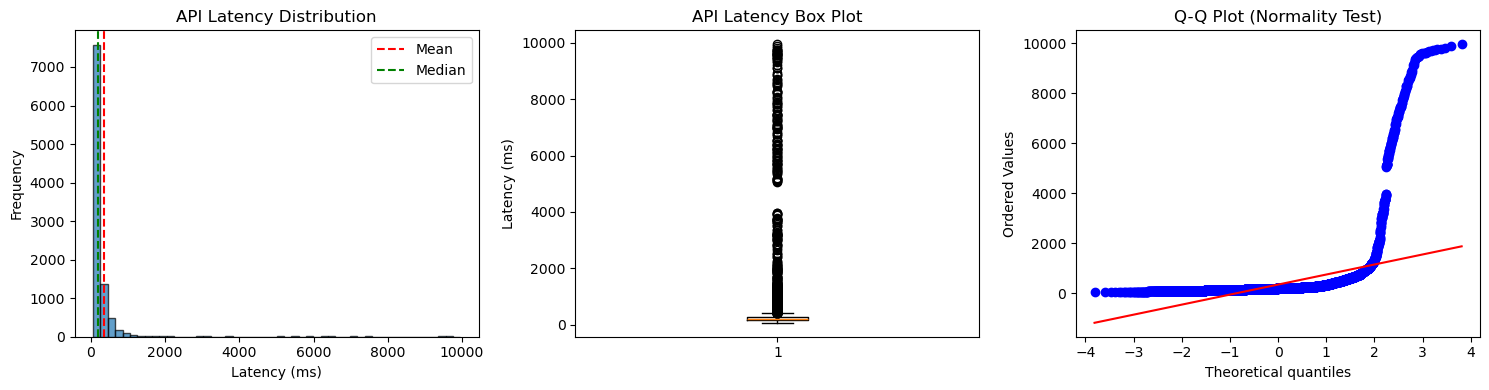

Mean: 355.67 ms
Median: 200.00 ms
Skewness: 8.07
Kurtosis: 70.45


In [99]:
#Distribution Shape of api_latency_ms
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['api_latency_ms'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('API Latency Distribution')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['api_latency_ms'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['api_latency_ms'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Box plot
axes[1].boxplot(df['api_latency_ms'])
axes[1].set_title('API Latency Box Plot')
axes[1].set_ylabel('Latency (ms)')

# Q-Q plot for normality
stats.probplot(df['api_latency_ms'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Test)')

plt.tight_layout()
plt.show()

# Statistical tests
print(f"Mean: {df['api_latency_ms'].mean():.2f} ms")
print(f"Median: {df['api_latency_ms'].median():.2f} ms")
print(f"Skewness: {df['api_latency_ms'].skew():.2f}")
print(f"Kurtosis: {df['api_latency_ms'].kurtosis():.2f}")

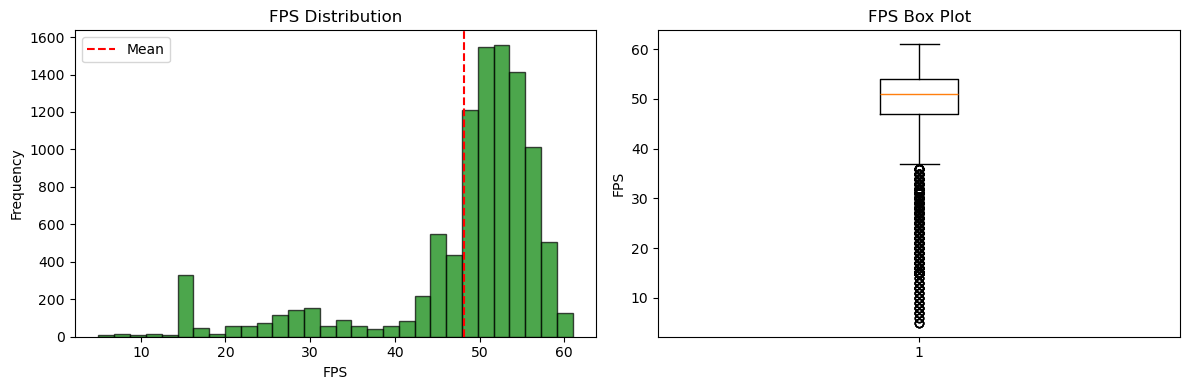

Mean FPS: 48.16
Median FPS: 51.00
Skewness: -1.96


In [100]:
#Distribution Shape of FPS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fps'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('FPS Distribution')
axes[0].set_xlabel('FPS')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['fps'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].boxplot(df['fps'])
axes[1].set_title('FPS Box Plot')
axes[1].set_ylabel('FPS')

plt.tight_layout()
plt.show()

print(f"Mean FPS: {df['fps'].mean():.2f}")
print(f"Median FPS: {df['fps'].median():.2f}")
print(f"Skewness: {df['fps'].skew():.2f}")

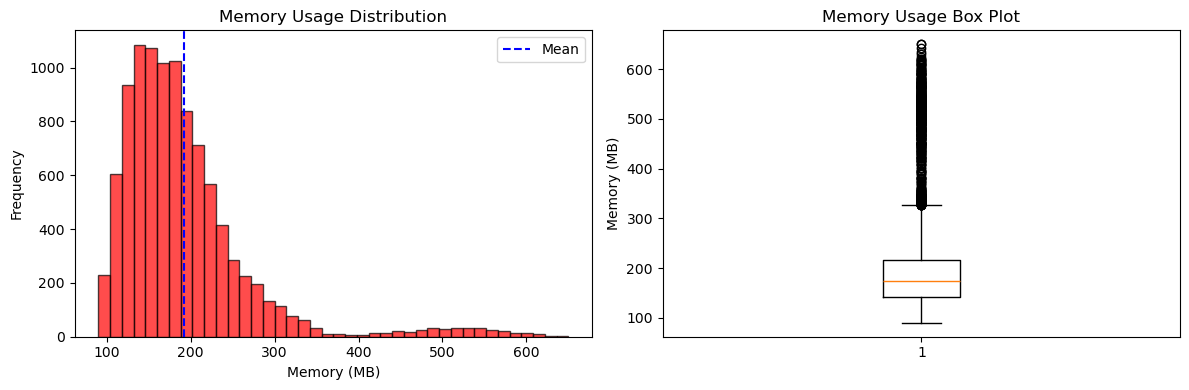

Mean Memory: 192.13 MB
Median Memory: 174.87 MB
Skewness: 2.47


In [101]:
#Distribution Shape of memory_mb
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['memory_mb'], bins=40, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('Memory Usage Distribution')
axes[0].set_xlabel('Memory (MB)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['memory_mb'].mean(), color='blue', linestyle='--', label='Mean')
axes[0].legend()

axes[1].boxplot(df['memory_mb'])
axes[1].set_title('Memory Usage Box Plot')
axes[1].set_ylabel('Memory (MB)')

plt.tight_layout()
plt.show()

print(f"Mean Memory: {df['memory_mb'].mean():.2f} MB")
print(f"Median Memory: {df['memory_mb'].median():.2f} MB")
print(f"Skewness: {df['memory_mb'].skew():.2f}")

In [102]:
from scipy import stats

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers), (len(outliers) / len(data)) * 100

metrics = ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']

print("Outlier Analysis (IQR Method):")
for metric in metrics:
    count, percentage = detect_outliers_iqr(df[metric])
    print(f"{metric:20s}: {count:5d} outliers ({percentage:5.2f}%)")

Outlier Analysis (IQR Method):
api_latency_ms      :  1252 outliers (12.52%)
ui_response_ms      :   863 outliers ( 8.63%)
fps                 :  1244 outliers (12.44%)
memory_mb           :   480 outliers ( 4.80%)


**<br><br>CATEGORY 3: Correlations & Relationships 🔗<br><br>**

Correlation between api_latency_ms and ui_response_ms: 0.192


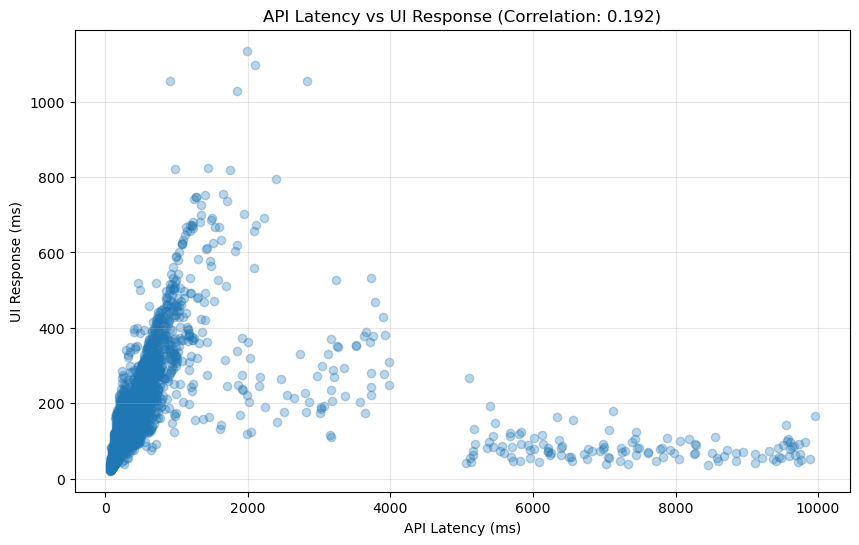

In [104]:
#Correlation Between api_latency_ms and ui_response_ms
correlation = df['api_latency_ms'].corr(df['ui_response_ms'])
print(f"Correlation between api_latency_ms and ui_response_ms: {correlation:.3f}")

#Scatter Plot
plt.figure(figsize=(10,6))
plt.scatter(df['api_latency_ms'] , df['ui_response_ms'],alpha=0.3)
plt.xlabel('API Latency (ms)')
plt.ylabel('UI Response (ms)')
plt.title(f'API Latency vs UI Response (Correlation: {correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

Correlation Between FPS and API Latency : -0.372


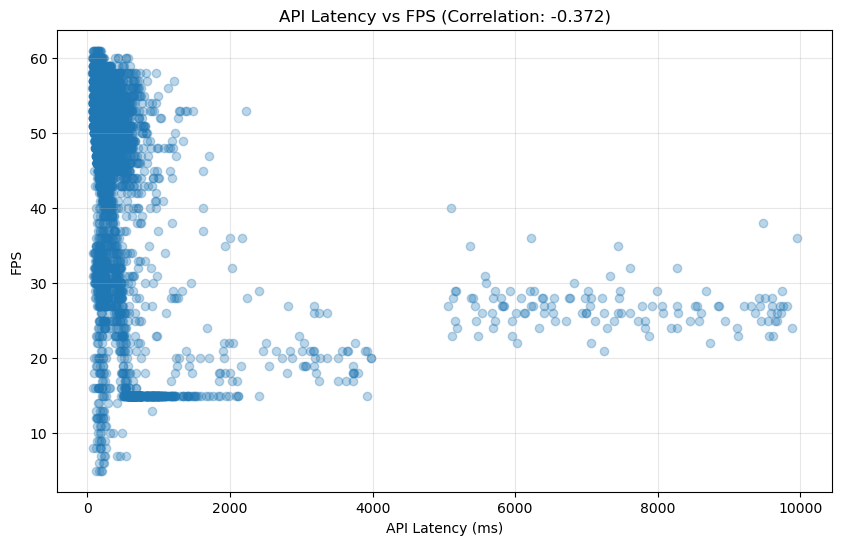

In [105]:
#Correlation Between FPS and api_latency_ms
correlation = df['api_latency_ms'].corr(df['fps'])
print(f'Correlation Between FPS and API Latency : {correlation:.3f}')

plt.figure(figsize=(10,6))
plt.scatter(df['api_latency_ms'],df['fps'], alpha=0.3)
plt.xlabel('API Latency (ms)')
plt.ylabel('FPS')
plt.title(f'API Latency vs FPS (Correlation: {correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

Correlation between memory_mb and fps: -0.174


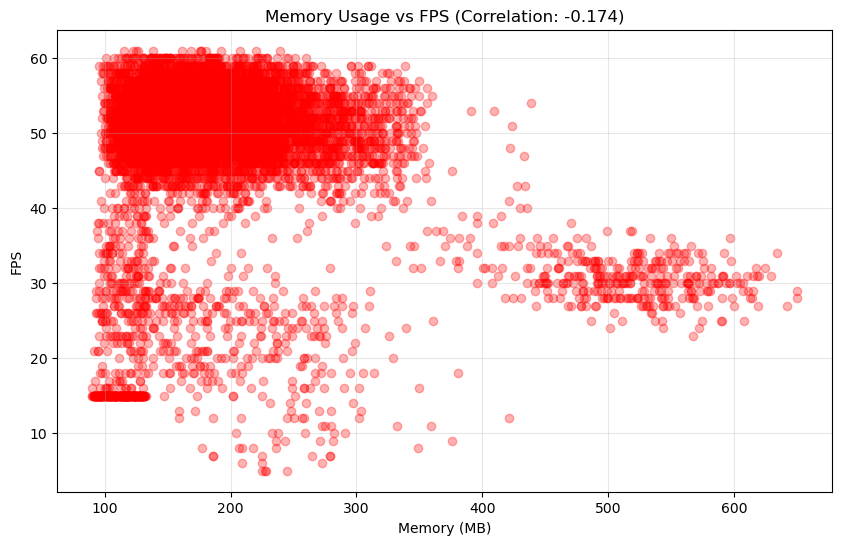

In [106]:
#Correlation Between memory_mb and fps
correlation = df['memory_mb'].corr(df['fps'])
print(f"Correlation between memory_mb and fps: {correlation:.3f}")

plt.figure(figsize=(10, 6))
plt.scatter(df['memory_mb'], df['fps'], alpha=0.3, color='red')
plt.xlabel('Memory (MB)')
plt.ylabel('FPS')
plt.title(f'Memory Usage vs FPS (Correlation: {correlation:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

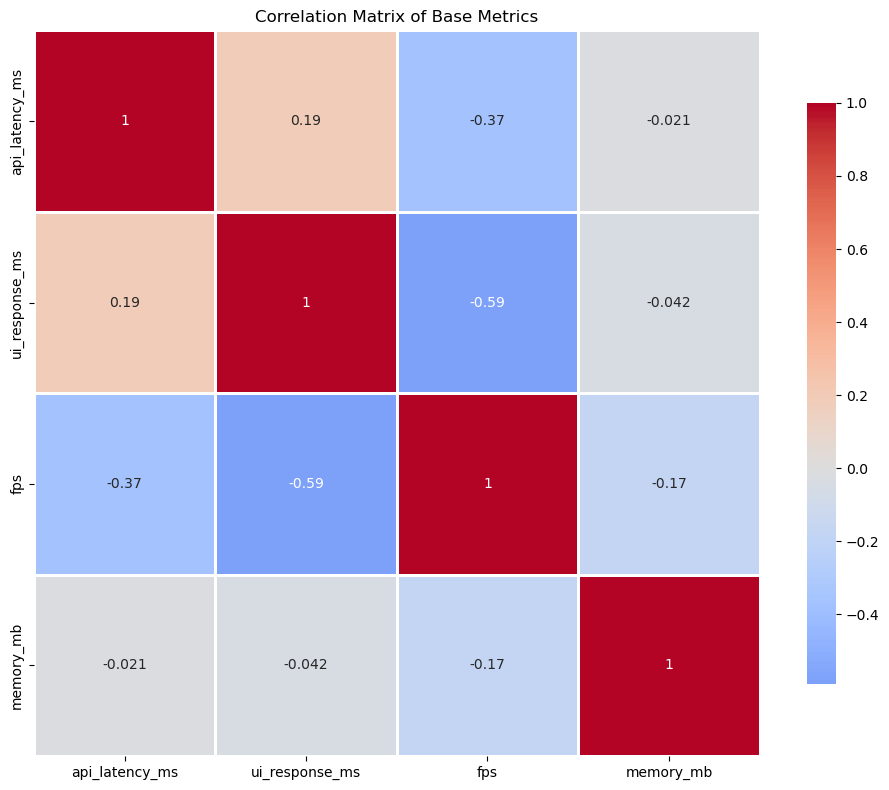

Correlation Matrix:
                api_latency_ms  ui_response_ms       fps  memory_mb
api_latency_ms        1.000000        0.191723 -0.372102  -0.020698
ui_response_ms        0.191723        1.000000 -0.589455  -0.041646
fps                  -0.372102       -0.589455  1.000000  -0.174098
memory_mb            -0.020698       -0.041646 -0.174098   1.000000


In [107]:
#How do these metrics correlate with each other 
import seaborn as sns

# Select base metrics
base_metrics = ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']
corr_matrix = df[base_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Base Metrics')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix)

**<br><br>CATEGORY 4: Anomaly Characteristics ⚠️<br><br>**

Number of anomaly sequences: 118
Average anomaly sequence length: 10.09 events
Median anomaly sequence length: 10 events
Min sequence length: 5
Max sequence length: 15


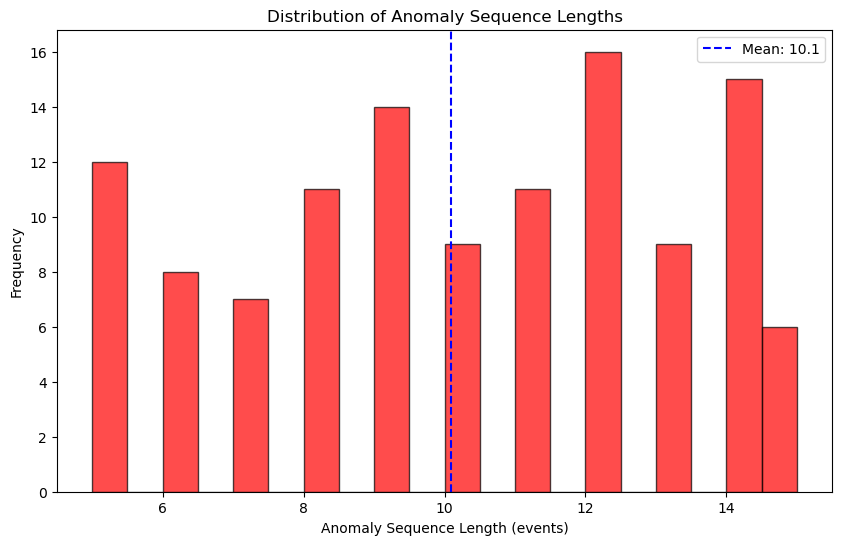

In [109]:
#Avg Duration of an anomaly event sequence
# Identify anomaly sequences (consecutive anomaly events)
df_sorted = df.sort_values(['session_id', 'timestamp']).reset_index(drop=True)
df_sorted['anomaly_group'] = (df_sorted['is_anomaly'] != df_sorted['is_anomaly'].shift()).cumsum()

anomaly_sequences = df_sorted[df_sorted['is_anomaly'] == 1].groupby('anomaly_group').size()

print(f"Number of anomaly sequences: {len(anomaly_sequences)}")
print(f"Average anomaly sequence length: {anomaly_sequences.mean():.2f} events")
print(f"Median anomaly sequence length: {anomaly_sequences.median():.0f} events")
print(f"Min sequence length: {anomaly_sequences.min()}")
print(f"Max sequence length: {anomaly_sequences.max()}")

plt.figure(figsize=(10, 6))
plt.hist(anomaly_sequences, bins=20, edgecolor='black', alpha=0.7, color='red')
plt.xlabel('Anomaly Sequence Length (events)')
plt.ylabel('Frequency')
plt.title('Distribution of Anomaly Sequence Lengths')
plt.axvline(anomaly_sequences.mean(), color='blue', linestyle='--', label=f'Mean: {anomaly_sequences.mean():.1f}')
plt.legend()
plt.show()

Normal vs Anomaly Comparison:

api_latency_ms:
  Normal mean:    237.65
  Anomaly mean:  1228.61
  Difference:     990.96 (+417.0%)

ui_response_ms:
  Normal mean:    106.42
  Anomaly mean:   155.57
  Difference:      49.16 (+46.2%)

fps:
  Normal mean:     49.80
  Anomaly mean:    36.01
  Difference:     -13.79 (-27.7%)

memory_mb:
  Normal mean:    178.01
  Anomaly mean:   296.52
  Difference:     118.51 (+66.6%)


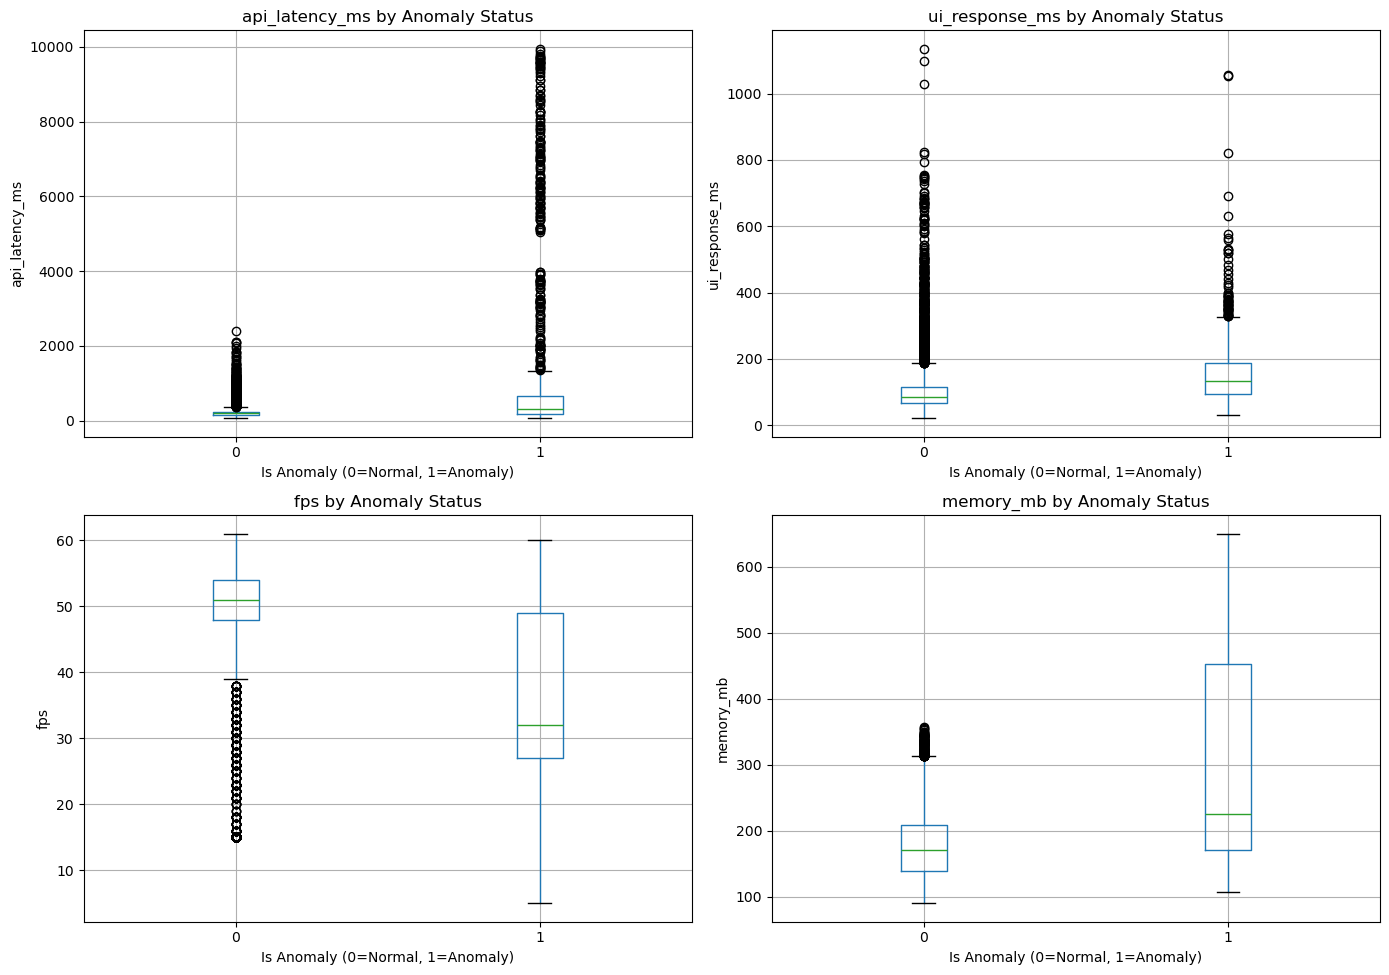

In [110]:
#How do metric values differ between normal and anomaly events?
metrics = ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']

print("Normal vs Anomaly Comparison:")
print("="*60)
for metric in metrics:
    normal_mean = df[df['is_anomaly'] == 0][metric].mean()
    anomaly_mean = df[df['is_anomaly'] == 1][metric].mean()
    difference = anomaly_mean - normal_mean
    percent_change = (difference / normal_mean) * 100
    
    print(f"\n{metric}:")
    print(f"  Normal mean:  {normal_mean:8.2f}")
    print(f"  Anomaly mean: {anomaly_mean:8.2f}")
    print(f"  Difference:   {difference:8.2f} ({percent_change:+.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    df.boxplot(column=metric, by='is_anomaly', ax=axes[idx])
    axes[idx].set_title(f'{metric} by Anomaly Status')
    axes[idx].set_xlabel('Is Anomaly (0=Normal, 1=Anomaly)')
    axes[idx].set_ylabel(metric)

plt.suptitle('')
plt.tight_layout()
plt.show()

API Latency by Anomaly Type:
                        mean  median   max
anomaly_type                              
api_timeout      6359.206897  6831.0  9950
latency_cascade  2327.918367  2163.5  3980
error_burst       530.464497   507.0  2227
fps_drop          222.139394   200.0   981
memory_leak       218.211236   200.0   714


<Figure size 1200x600 with 0 Axes>

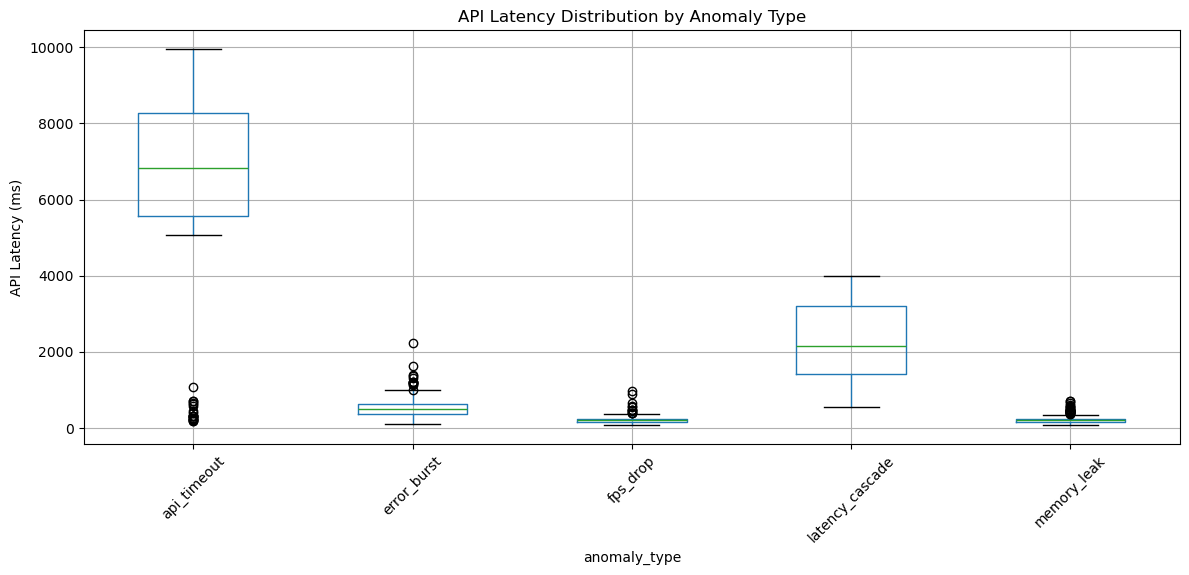

In [111]:
#Q32: Which anomaly type has the highest average API latency?
anomaly_data = df[df['is_anomaly'] == 1]

latency_by_type = anomaly_data.groupby('anomaly_type')['api_latency_ms'].agg(['mean', 'median', 'max'])
print("API Latency by Anomaly Type:")
print(latency_by_type.sort_values('mean', ascending=False))

plt.figure(figsize=(12, 6))
anomaly_data.boxplot(column='api_latency_ms', by='anomaly_type', figsize=(12, 6))
plt.xticks(rotation=45)
plt.title('API Latency Distribution by Anomaly Type')
plt.suptitle('')
plt.ylabel('API Latency (ms)')
plt.tight_layout()
plt.show()

FPS by Anomaly Type:
                      mean  median  min
anomaly_type                           
fps_drop         20.369697    19.0    5
latency_cascade  24.530612    21.0   15
api_timeout      30.655172    27.0   21
memory_leak      34.249438    31.0   23
error_burst      51.591716    52.0   39


<Figure size 1200x600 with 0 Axes>

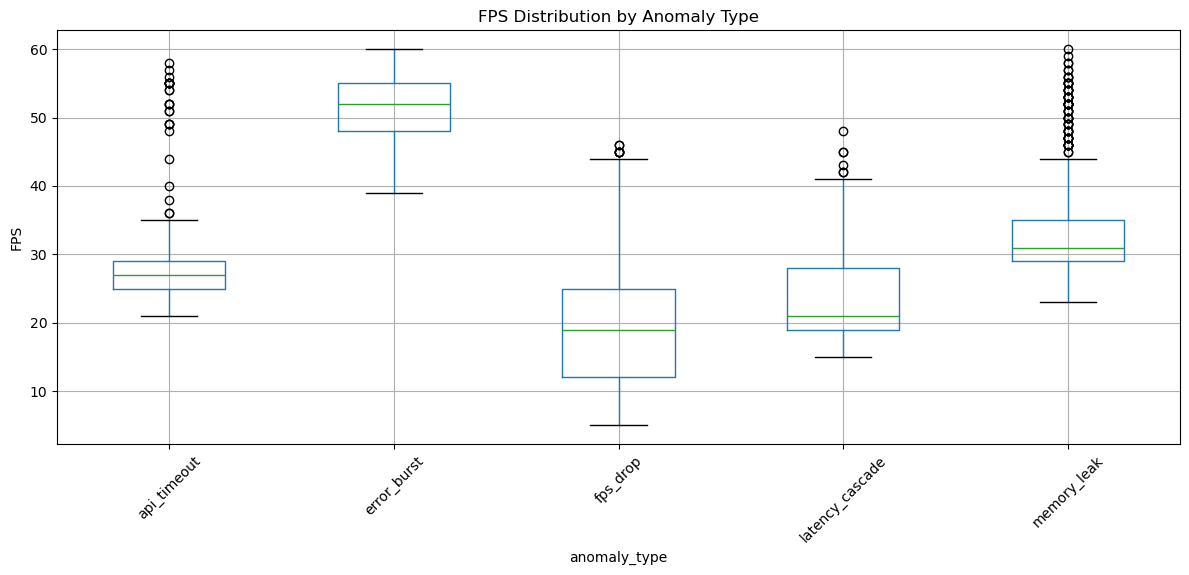

In [112]:
#Which anomaly type causes the most FPS drops?
fps_by_type = anomaly_data.groupby('anomaly_type')['fps'].agg(['mean', 'median', 'min'])
print("FPS by Anomaly Type:")
print(fps_by_type.sort_values('mean'))

plt.figure(figsize=(12, 6))
anomaly_data.boxplot(column='fps', by='anomaly_type', figsize=(12, 6))
plt.xticks(rotation=45)
plt.title('FPS Distribution by Anomaly Type')
plt.suptitle('')
plt.ylabel('FPS')
plt.tight_layout()
plt.show()

**<br><br>CATEGORY 5: Temporal Patterns 📅<br><br>**

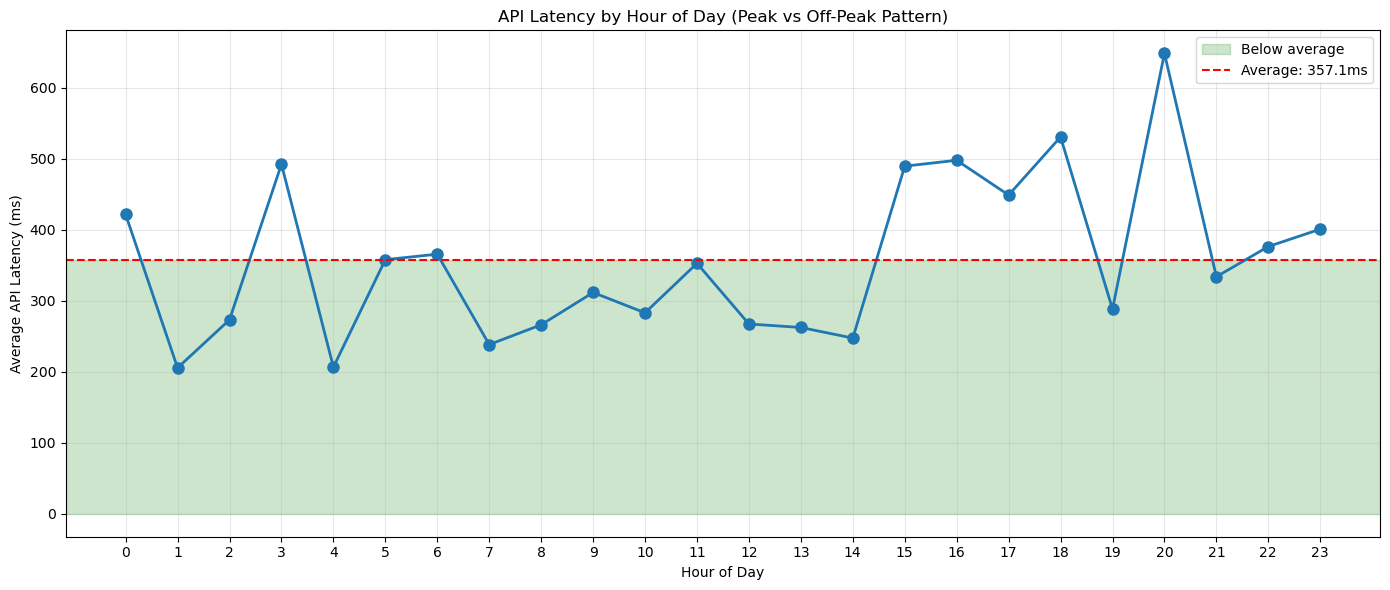

Hourly API Latency Statistics:
Peak hours (9-23) average: 380.20 ms
Off-peak hours (0-8) average: 311.84 ms


In [114]:
#How does API latency vary by hour of the day?
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

hourly_latency = df.groupby('hour')['api_latency_ms'].mean()

plt.figure(figsize=(14, 6))
plt.plot(hourly_latency.index, hourly_latency.values, marker='o', linewidth=2, markersize=8)
plt.axhspan(0, hourly_latency.mean(), alpha=0.2, color='green', label='Below average')
plt.axhline(hourly_latency.mean(), color='red', linestyle='--', label=f'Average: {hourly_latency.mean():.1f}ms')
plt.xlabel('Hour of Day')
plt.ylabel('Average API Latency (ms)')
plt.title('API Latency by Hour of Day (Peak vs Off-Peak Pattern)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Hourly API Latency Statistics:")
print(f"Peak hours (9-23) average: {df[df['hour'].between(9, 23)]['api_latency_ms'].mean():.2f} ms")
print(f"Off-peak hours (0-8) average: {df[~df['hour'].between(9, 23)]['api_latency_ms'].mean():.2f} ms")

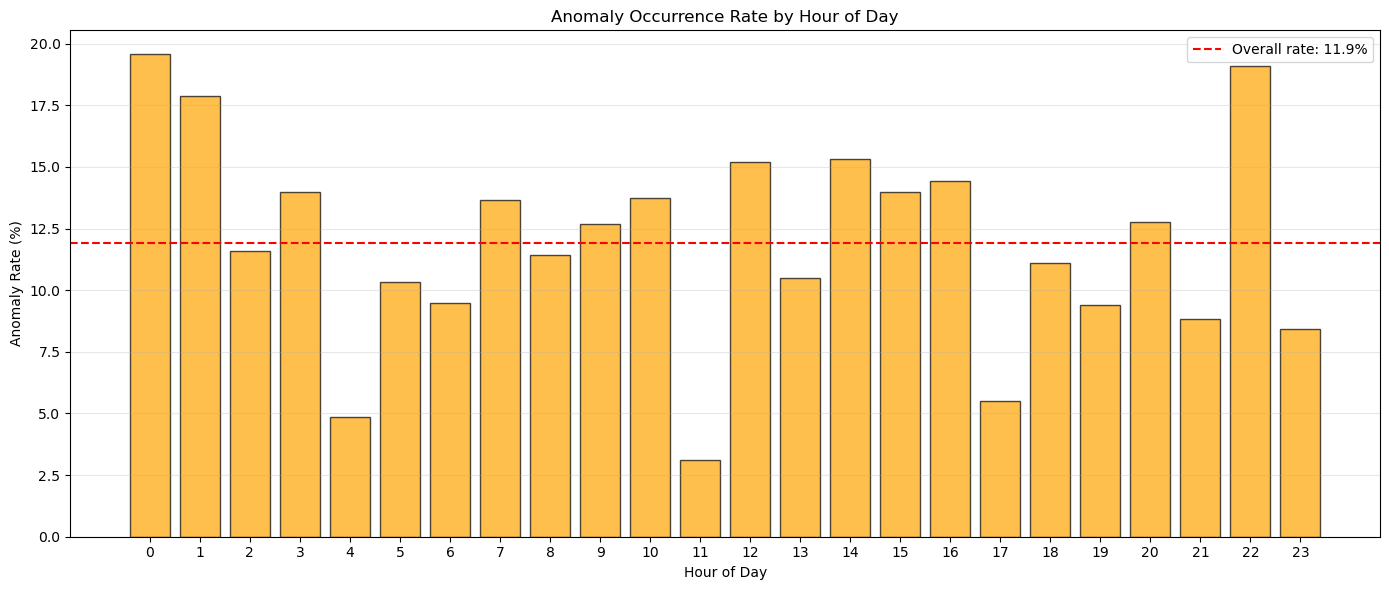

Peak hours anomaly rate: 11.67%
Off-peak anomaly rate: 12.35%


In [115]:
#Do anomalies occur more frequently at certain times of day?
hourly_anomaly_rate = df.groupby('hour')['is_anomaly'].mean() * 100

plt.figure(figsize=(14, 6))
plt.bar(hourly_anomaly_rate.index, hourly_anomaly_rate.values, alpha=0.7, color='orange', edgecolor='black')
plt.axhline(df['is_anomaly'].mean() * 100, color='red', linestyle='--', 
            label=f'Overall rate: {df["is_anomaly"].mean()*100:.1f}%')
plt.xlabel('Hour of Day')
plt.ylabel('Anomaly Rate (%)')
plt.title('Anomaly Occurrence Rate by Hour of Day')
plt.xticks(range(24))
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Peak hours anomaly rate: {df[df['hour'].between(9, 23)]['is_anomaly'].mean()*100:.2f}%")
print(f"Off-peak anomaly rate: {df[~df['hour'].between(9, 23)]['is_anomaly'].mean()*100:.2f}%")

**<br><br>CATEGORY 6: Version Analysis 📱<br><br>**

API Latency by App Version:
                   mean  median          std
app_version                                 
1.2.0        406.883235   214.5  1036.180845
1.1.0        353.689020   201.0   715.681673
1.0.0        349.846250   182.0   930.669654
1.3.0        290.476735   193.0   612.863957


<Figure size 1200x600 with 0 Axes>

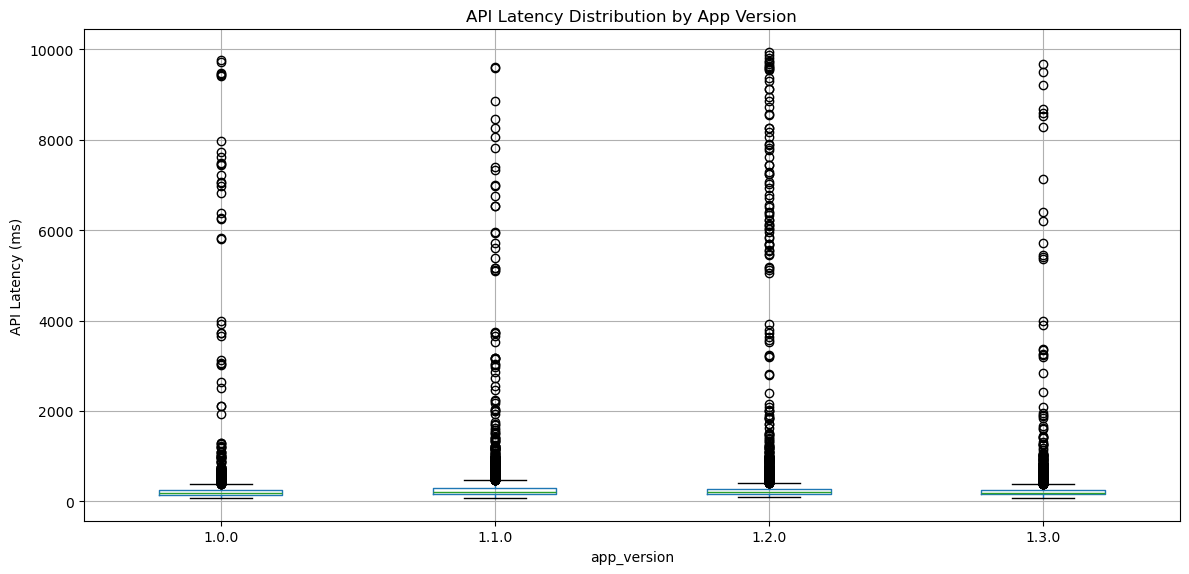

In [117]:
#Which app version has the highest average API latency?
version_latency = df.groupby('app_version')['api_latency_ms'].agg(['mean', 'median', 'std'])
print("API Latency by App Version:")
print(version_latency.sort_values('mean', ascending=False))

plt.figure(figsize=(12, 6))
df.boxplot(column='api_latency_ms', by='app_version', figsize=(12, 6))
plt.title('API Latency Distribution by App Version')
plt.suptitle('')
plt.ylabel('API Latency (ms)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Memory Growth Rate by Version:
                 mean    median         max
app_version                                
1.2.0        4.121682  4.789954  141.416063
1.1.0        2.277407  1.615676  131.120468
1.3.0        2.134477  1.786593  106.779577
1.0.0        2.127913  2.000400  123.583727

Anomaly Type Distribution by Version:
anomaly_type  api_timeout  error_burst  fps_drop  latency_cascade  memory_leak
app_version                                                                   
1.0.0                  25           17         9               19           52
1.1.0                  26          306        14               31           43
1.2.0                  76            0        30               29          336
1.3.0                  18           15       112               19           14

Version 1.2.0 memory leak anomalies: 336 (71.3% of its anomalies)


<Figure size 1200x600 with 0 Axes>

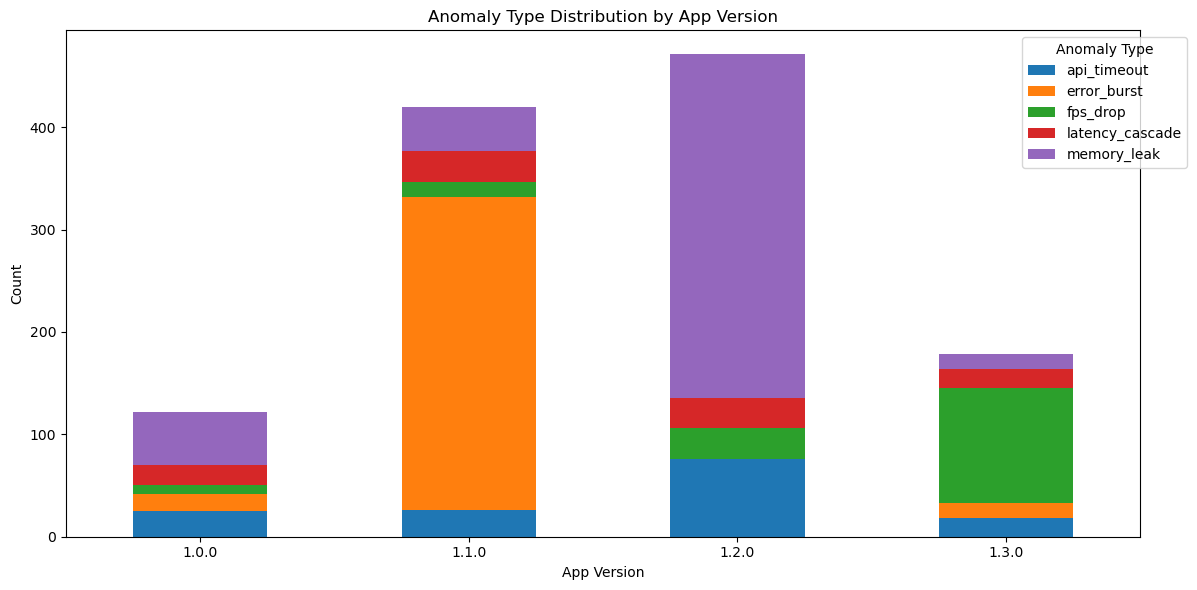

In [118]:
#Does version 1.2.0 show more memory leak patterns than others?
# Memory growth rate by version
memory_growth_by_version = df.groupby('app_version')['memory_growth_rate'].agg(['mean', 'median', 'max'])
print("Memory Growth Rate by Version:")
print(memory_growth_by_version.sort_values('mean', ascending=False))

# Anomaly type distribution by version
version_anomalies = df[df['is_anomaly']==1].groupby(['app_version', 'anomaly_type']).size().unstack(fill_value=0)
print("\nAnomaly Type Distribution by Version:")
print(version_anomalies)

# Focus on memory_leak for version 1.2.0
v120_memory_leaks = df[(df['app_version']=='1.2.0') & (df['anomaly_type']=='memory_leak')].shape[0]
total_v120_anomalies = df[(df['app_version']=='1.2.0') & (df['is_anomaly']==1)].shape[0]

print(f"\nVersion 1.2.0 memory leak anomalies: {v120_memory_leaks} ({v120_memory_leaks/total_v120_anomalies*100:.1f}% of its anomalies)")

plt.figure(figsize=(12, 6))
version_anomalies.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Anomaly Type Distribution by App Version')
plt.xlabel('App Version')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Anomaly Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

API Latency by Network Type:
                    mean  median         std  count
network_type                                       
wifi          340.611111   184.0  936.414242   6300
5g            361.476154   221.0  703.109276   2600
4g            428.221818   291.0  649.524160   1100

WiFi average latency: 340.61 ms
4G average latency: 428.22 ms
Difference: 87.61 ms (25.7% higher on 4G)


<Figure size 1000x600 with 0 Axes>

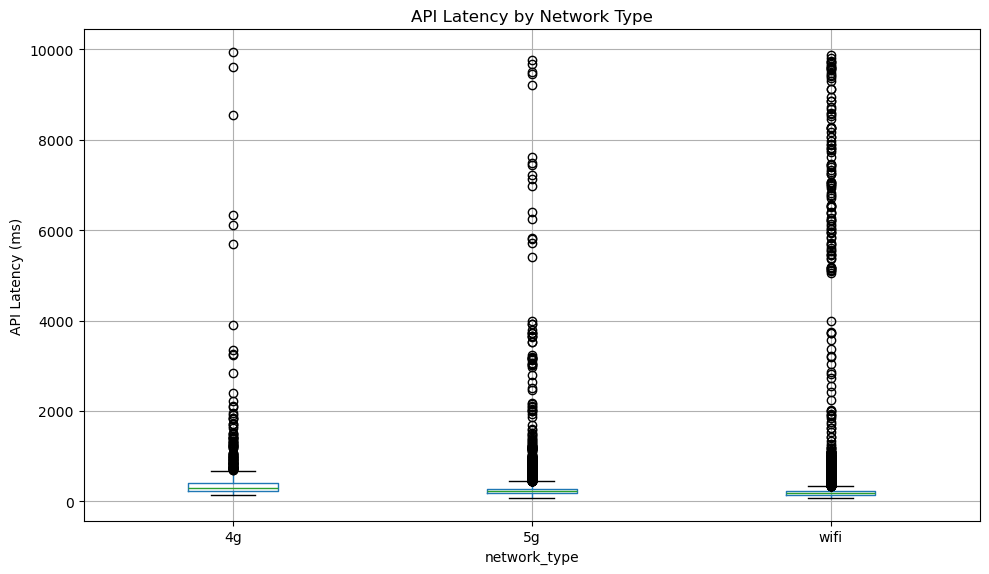

In [119]:
# What is the average latency difference between WiFi and 4G?
network_latency = df.groupby('network_type')['api_latency_ms'].agg(['mean', 'median', 'std', 'count'])
print("API Latency by Network Type:")
print(network_latency.sort_values('mean'))

wifi_mean = network_latency.loc['wifi', 'mean']
g4_mean = network_latency.loc['4g', 'mean']
difference = g4_mean - wifi_mean
percent_diff = (difference / wifi_mean) * 100

print(f"\nWiFi average latency: {wifi_mean:.2f} ms")
print(f"4G average latency: {g4_mean:.2f} ms")
print(f"Difference: {difference:.2f} ms ({percent_diff:.1f}% higher on 4G)")

plt.figure(figsize=(10, 6))
df.boxplot(column='api_latency_ms', by='network_type', figsize=(10, 6))
plt.title('API Latency by Network Type')
plt.suptitle('')
plt.ylabel('API Latency (ms)')
plt.tight_layout()
plt.show()

Latency Variance by Network Type:
                     std            var
network_type                           
wifi          936.414242  876871.632199
5g            703.109276  494362.653529
4g            649.524160  421881.634100

Coefficient of Variation (CV = std/mean):
network_type
wifi    2.749218
5g      1.945106
4g      1.516794
Name: api_latency_ms, dtype: float64


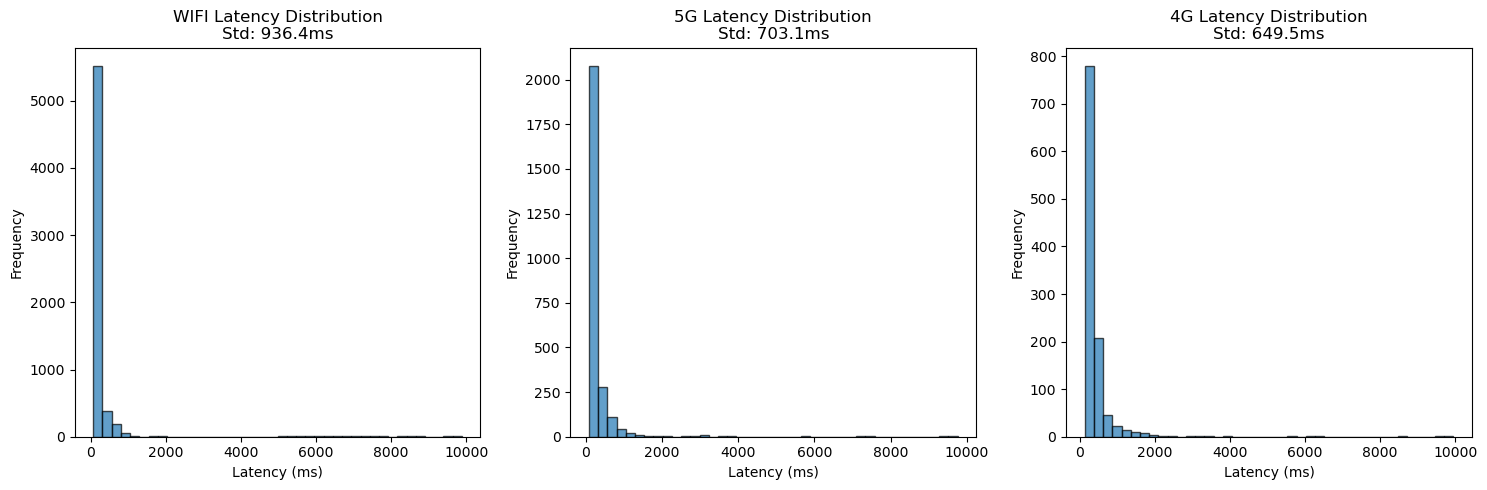

In [120]:
# Does 4G show higher latency variance than WiFi?
network_variance = df.groupby('network_type')['api_latency_ms'].agg(['std', 'var'])
print("Latency Variance by Network Type:")
print(network_variance.sort_values('std', ascending=False))

# Coefficient of variation (normalized measure)
cv_by_network = df.groupby('network_type')['api_latency_ms'].apply(
    lambda x: x.std() / x.mean()
)
print("\nCoefficient of Variation (CV = std/mean):")
print(cv_by_network.sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, network in enumerate(['wifi', '5g', '4g']):
    network_data = df[df['network_type'] == network]['api_latency_ms']
    axes[idx].hist(network_data, bins=40, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{network.upper()} Latency Distribution\nStd: {network_data.std():.1f}ms')
    axes[idx].set_xlabel('Latency (ms)')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Anomaly Rate by Session Health:
                     mean  count
session_health                  
0.50            22.000000    250
0.70            10.206897   1450
0.85            14.604651   2150
0.95            10.714286   2100
1.00            11.086420   4050


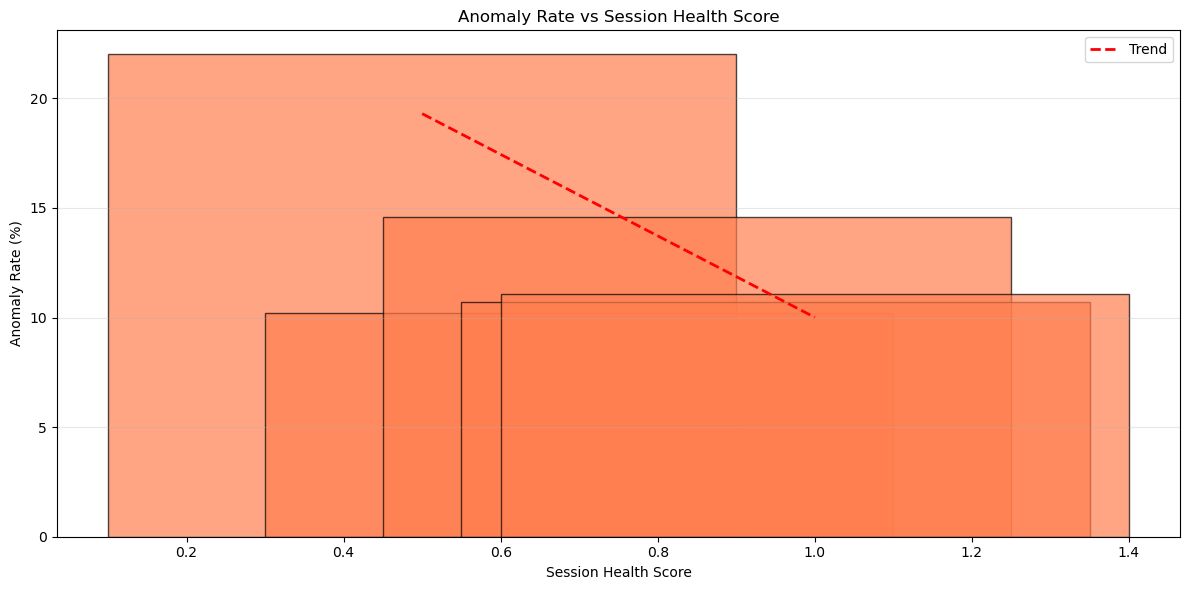

In [121]:
# Do sessions with lower health scores have more anomalies?
health_anomaly = df.groupby('session_health')['is_anomaly'].agg(['mean', 'count'])
health_anomaly['mean'] *= 100  # Convert to percentage
health_anomaly = health_anomaly.sort_index()

print("Anomaly Rate by Session Health:")
print(health_anomaly)

plt.figure(figsize=(12, 6))
plt.bar(health_anomaly.index, health_anomaly['mean'], alpha=0.7, edgecolor='black', color='coral')
plt.xlabel('Session Health Score')
plt.ylabel('Anomaly Rate (%)')
plt.title('Anomaly Rate vs Session Health Score')
plt.grid(True, alpha=0.3, axis='y')

# Add trend line
z = np.polyfit(health_anomaly.index, health_anomaly['mean'], 1)
p = np.poly1d(z)
plt.plot(health_anomaly.index, p(health_anomaly.index), "r--", linewidth=2, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

Total sessions: 200
Sessions with at least one anomaly: 118
Percentage: 59.00%


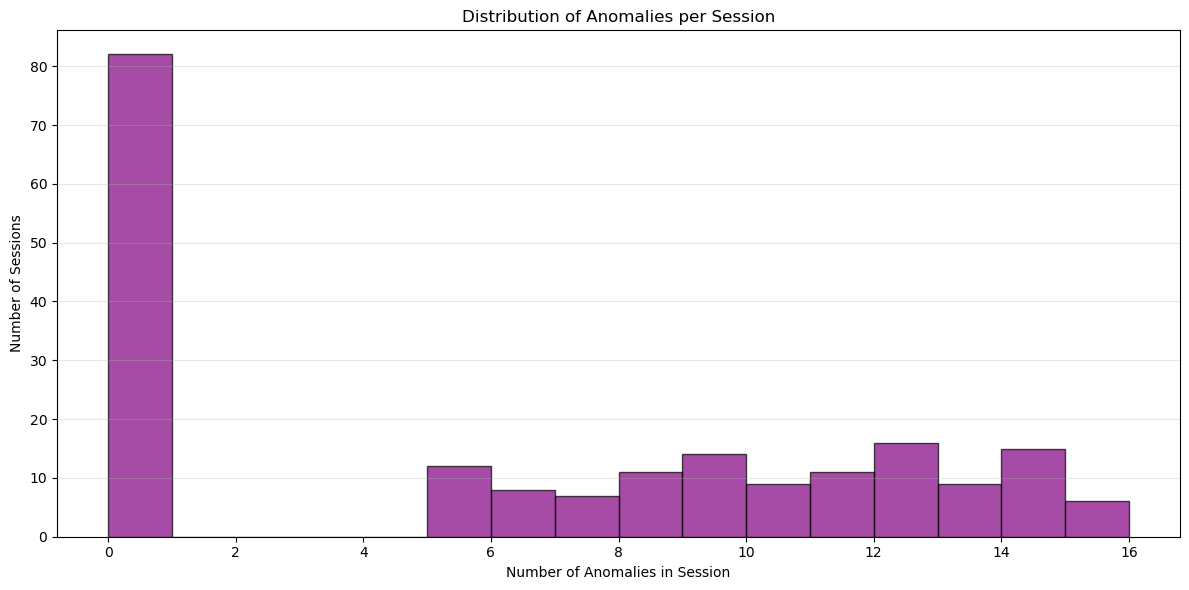


Average anomalies per session: 5.96
Sessions with 0 anomalies: 82
Sessions with 1-5 anomalies: 12
Sessions with 6+ anomalies: 106


In [122]:
# What percentage of sessions contain at least one anomaly?
sessions_with_anomaly = df.groupby('session_id')['is_anomaly'].max()
pct_sessions_with_anomaly = sessions_with_anomaly.mean() * 100

total_sessions = df['session_id'].nunique()
sessions_with_at_least_one = sessions_with_anomaly.sum()

print(f"Total sessions: {total_sessions}")
print(f"Sessions with at least one anomaly: {sessions_with_at_least_one}")
print(f"Percentage: {pct_sessions_with_anomaly:.2f}%")

# Distribution of anomalies per session
anomalies_per_session = df.groupby('session_id')['is_anomaly'].sum()

plt.figure(figsize=(12, 6))
plt.hist(anomalies_per_session, bins=range(0, anomalies_per_session.max()+2), 
         alpha=0.7, edgecolor='black', color='purple')
plt.xlabel('Number of Anomalies in Session')
plt.ylabel('Number of Sessions')
plt.title('Distribution of Anomalies per Session')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nAverage anomalies per session: {anomalies_per_session.mean():.2f}")
print(f"Sessions with 0 anomalies: {(anomalies_per_session == 0).sum()}")
print(f"Sessions with 1-5 anomalies: {((anomalies_per_session >= 1) & (anomalies_per_session <= 5)).sum()}")
print(f"Sessions with 6+ anomalies: {(anomalies_per_session > 5).sum()}")

Average API Latency by Event Index (First 10 Events):
event_index
0    900.785
1    665.835
2    429.690
3    213.300
4    210.570
5    204.900
6    208.920
7    250.155
8    281.550
9    274.935
Name: api_latency_ms, dtype: float64


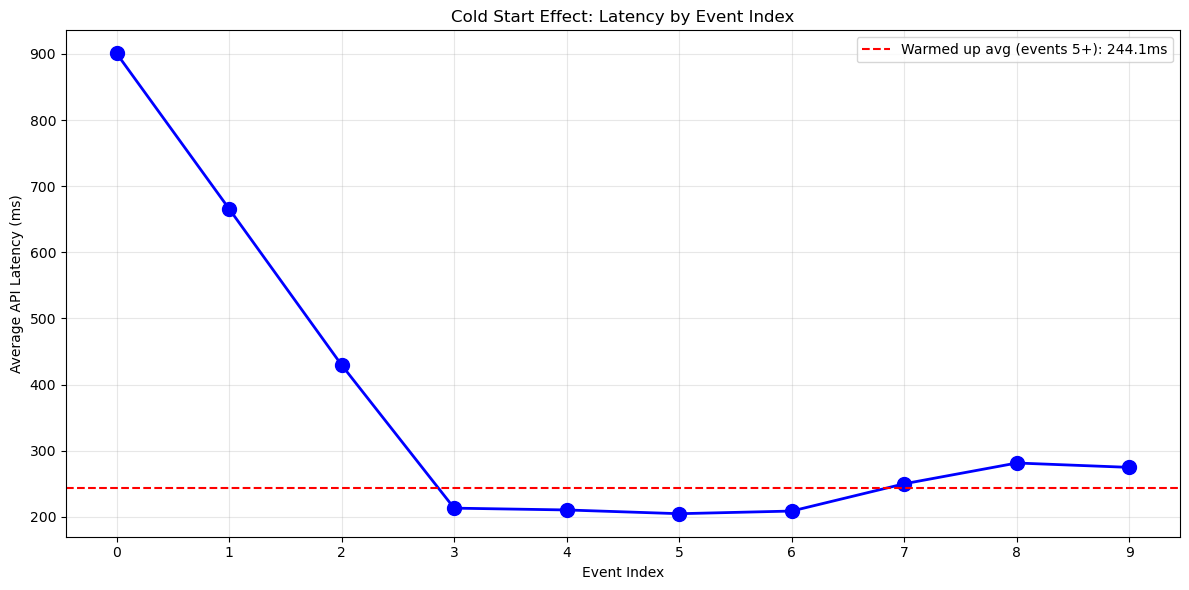


Event 0 (first) latency: 900.78 ms
Event 5 latency: 204.90 ms
Cold start penalty: 695.88 ms (339.6% higher)


In [123]:
#How much higher is latency in event 0 vs event 5
# Get first 10 events of each session
df['event_index'] = df.groupby('session_id').cumcount()
early_events = df[df['event_index'] < 10]

latency_by_event_index = early_events.groupby('event_index')['api_latency_ms'].mean()

print("Average API Latency by Event Index (First 10 Events):")
print(latency_by_event_index)

plt.figure(figsize=(12, 6))
plt.plot(latency_by_event_index.index, latency_by_event_index.values, 
         marker='o', linewidth=2, markersize=10, color='blue')
plt.axhline(latency_by_event_index[5:].mean(), color='red', linestyle='--', 
            label=f'Warmed up avg (events 5+): {latency_by_event_index[5:].mean():.1f}ms')
plt.xlabel('Event Index')
plt.ylabel('Average API Latency (ms)')
plt.title('Cold Start Effect: Latency by Event Index')
plt.xticks(range(10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

event0_latency = latency_by_event_index[0]
event5_latency = latency_by_event_index[5]
difference = event0_latency - event5_latency
percent_diff = (difference / event5_latency) * 100

print(f"\nEvent 0 (first) latency: {event0_latency:.2f} ms")
print(f"Event 5 latency: {event5_latency:.2f} ms")
print(f"Cold start penalty: {difference:.2f} ms ({percent_diff:.1f}% higher)")

Average latency WITH errors: 2496.99 ms
Average latency WITHOUT errors: 250.78 ms
Difference: 2246.21 ms

Correlation between api_latency and error_code: 0.532


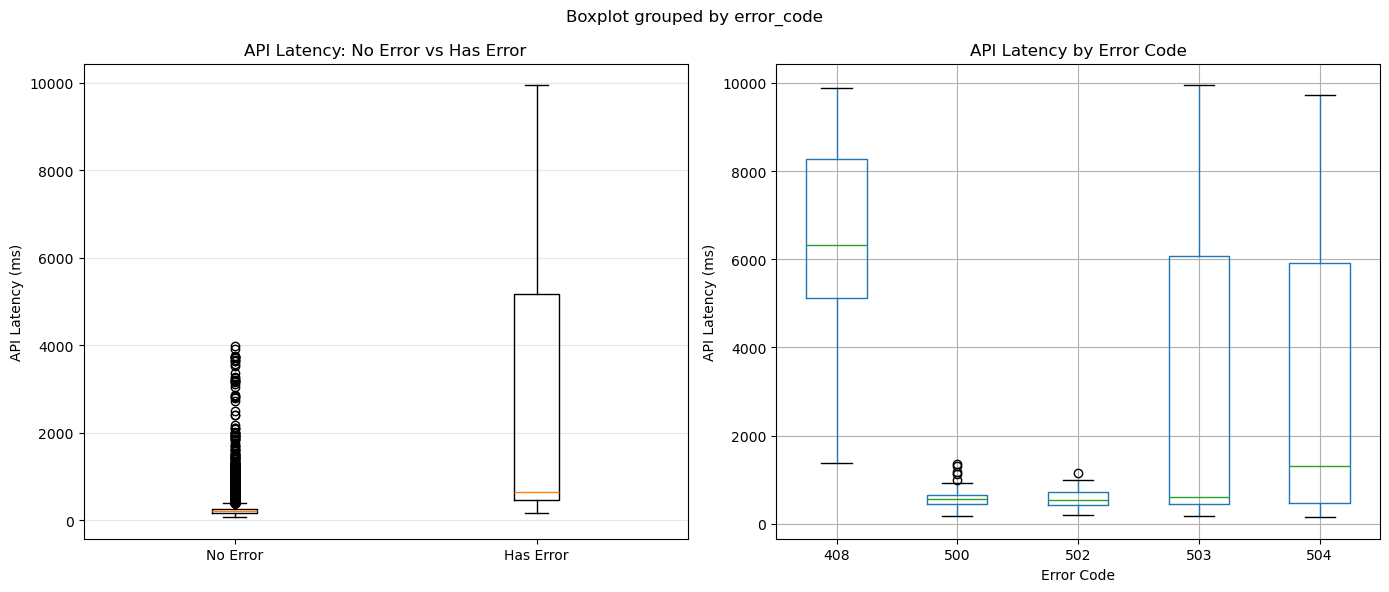


Error occurrence by latency bucket:
latency_bucket
<500ms          1.556979
500-1000ms     25.117005
1000-2000ms    13.445378
>2000ms        80.978261
dtype: float64


In [124]:
#Do error codes correlate with high API latency?
# Compare latency with vs without errors
error_latency = df[df['error_code'] != 0]['api_latency_ms']
no_error_latency = df[df['error_code'] == 0]['api_latency_ms']

print(f"Average latency WITH errors: {error_latency.mean():.2f} ms")
print(f"Average latency WITHOUT errors: {no_error_latency.mean():.2f} ms")
print(f"Difference: {error_latency.mean() - no_error_latency.mean():.2f} ms")

# Correlation
correlation = df['api_latency_ms'].corr(df['error_code'])
print(f"\nCorrelation between api_latency and error_code: {correlation:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot([no_error_latency, error_latency], labels=['No Error', 'Has Error'])
axes[0].set_ylabel('API Latency (ms)')
axes[0].set_title('API Latency: No Error vs Has Error')
axes[0].grid(True, alpha=0.3, axis='y')

# Latency by specific error codes
error_data = df[df['error_code'] != 0]
error_data.boxplot(column='api_latency_ms', by='error_code', ax=axes[1])
axes[1].set_title('API Latency by Error Code')
axes[1].set_xlabel('Error Code')
axes[1].set_ylabel('API Latency (ms)')

plt.tight_layout()
plt.show()

# Error code distribution at different latency levels
print("\nError occurrence by latency bucket:")
df['latency_bucket'] = pd.cut(df['api_latency_ms'], bins=[0, 500, 1000, 2000, 10000], 
                               labels=['<500ms', '500-1000ms', '1000-2000ms', '>2000ms'])
error_rate_by_latency = df.groupby('latency_bucket').apply(
    lambda x: (x['error_code'] != 0).mean() * 100
)
print(error_rate_by_latency)

**<br><br>CATEGORY 7: Feature Engineering Validation 🔧<br><br>**

Z-Score Statistics:
Normal events - mean: -0.117, std: 0.875
Anomaly events - mean: 0.270, std: 0.932


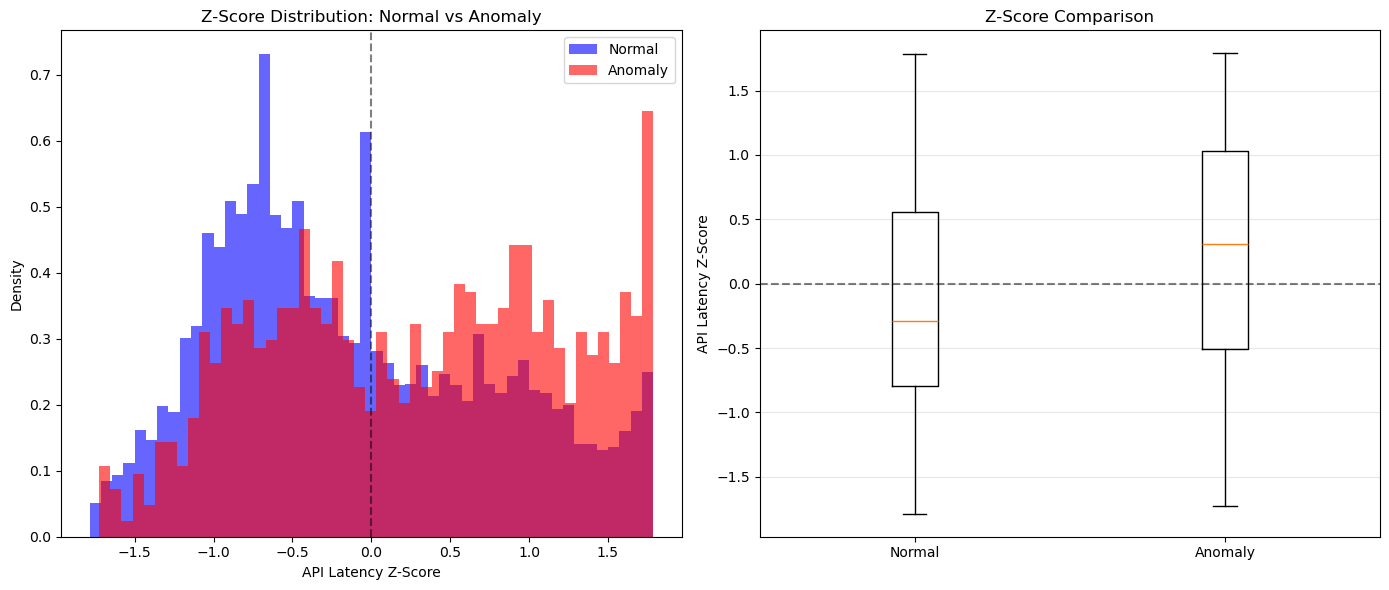


Separation at z-score > 2.0:
% of anomalies above threshold: 0.0%
% of normal events above threshold: 0.0%


In [126]:
#Do z-score features effectively separate anomalies from normal events?
# Compare z-score distributions
normal_zscore = df[df['is_anomaly'] == 0]['api_latency_ms_zscore']
anomaly_zscore = df[df['is_anomaly'] == 1]['api_latency_ms_zscore']

print("Z-Score Statistics:")
print(f"Normal events - mean: {normal_zscore.mean():.3f}, std: {normal_zscore.std():.3f}")
print(f"Anomaly events - mean: {anomaly_zscore.mean():.3f}, std: {anomaly_zscore.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
axes[0].hist(normal_zscore, bins=50, alpha=0.6, label='Normal', color='blue', density=True)
axes[0].hist(anomaly_zscore, bins=50, alpha=0.6, label='Anomaly', color='red', density=True)
axes[0].set_xlabel('API Latency Z-Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Z-Score Distribution: Normal vs Anomaly')
axes[0].legend()
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

# Box plot
axes[1].boxplot([normal_zscore, anomaly_zscore], labels=['Normal', 'Anomaly'])
axes[1].set_ylabel('API Latency Z-Score')
axes[1].set_title('Z-Score Comparison')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Separation quality
threshold = 2.0  # Common z-score threshold
anomalies_above_threshold = (anomaly_zscore > threshold).mean() * 100
normals_above_threshold = (normal_zscore > threshold).mean() * 100

print(f"\nSeparation at z-score > {threshold}:")
print(f"% of anomalies above threshold: {anomalies_above_threshold:.1f}%")
print(f"% of normal events above threshold: {normals_above_threshold:.1f}%")

FPS Change Rate Comparison:
Normal events: mean = 0.0537, std = 0.2538
FPS drop anomalies: mean = 0.0536, std = 0.7192


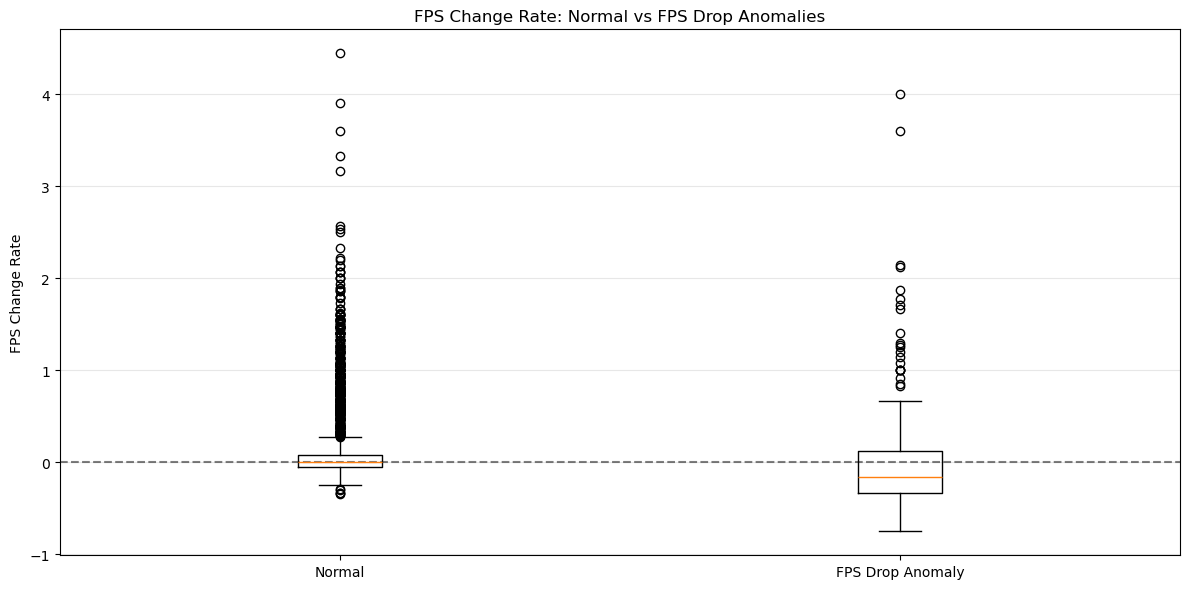


% with FPS change < -20%:
Normal: 0.1%
FPS drop anomaly: 41.2%


In [127]:
#Does fps_change_rate show larger values during FPS drop anomalies?
fps_drop_events = df[df['anomaly_type'] == 'fps_drop']
normal_events = df[df['is_anomaly'] == 0]

print("FPS Change Rate Comparison:")
print(f"Normal events: mean = {normal_events['fps_change_rate'].mean():.4f}, std = {normal_events['fps_change_rate'].std():.4f}")
print(f"FPS drop anomalies: mean = {fps_drop_events['fps_change_rate'].mean():.4f}, std = {fps_drop_events['fps_change_rate'].std():.4f}")

plt.figure(figsize=(12, 6))
plt.boxplot([normal_events['fps_change_rate'], fps_drop_events['fps_change_rate']], 
            labels=['Normal', 'FPS Drop Anomaly'])
plt.ylabel('FPS Change Rate')
plt.title('FPS Change Rate: Normal vs FPS Drop Anomalies')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Percentage with large negative changes
large_drop_normal = (normal_events['fps_change_rate'] < -0.2).mean() * 100
large_drop_anomaly = (fps_drop_events['fps_change_rate'] < -0.2).mean() * 100

print(f"\n% with FPS change < -20%:")
print(f"Normal: {large_drop_normal:.1f}%")
print(f"FPS drop anomaly: {large_drop_anomaly:.1f}%")

Memory Growth Rate Comparison:
Normal events: mean = 1.21 MB/event
Memory leak anomalies: mean = 33.98 MB/event


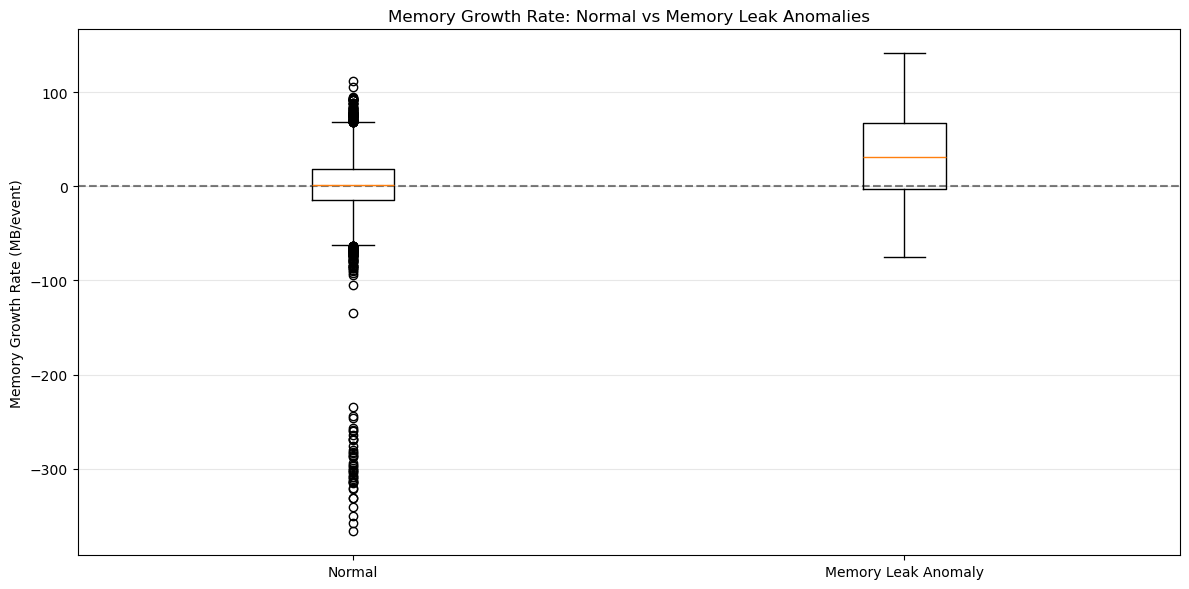

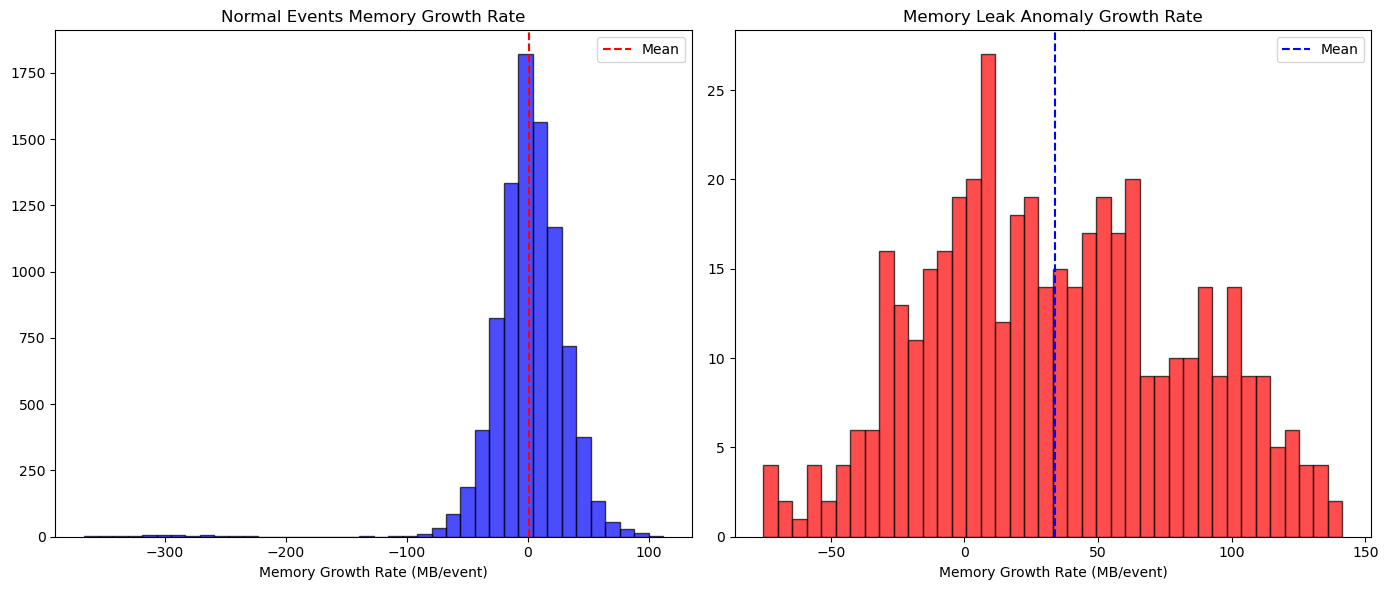

In [128]:
#Does memory_growth_rate show positive trends during memory leak anomalies?
memory_leak_events = df[df['anomaly_type'] == 'memory_leak']
normal_events = df[df['is_anomaly'] == 0]

print("Memory Growth Rate Comparison:")
print(f"Normal events: mean = {normal_events['memory_growth_rate'].mean():.2f} MB/event")
print(f"Memory leak anomalies: mean = {memory_leak_events['memory_growth_rate'].mean():.2f} MB/event")

plt.figure(figsize=(12, 6))
plt.boxplot([normal_events['memory_growth_rate'], memory_leak_events['memory_growth_rate']], 
            labels=['Normal', 'Memory Leak Anomaly'])
plt.ylabel('Memory Growth Rate (MB/event)')
plt.title('Memory Growth Rate: Normal vs Memory Leak Anomalies')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(normal_events['memory_growth_rate'], bins=40, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Normal Events Memory Growth Rate')
axes[0].set_xlabel('Memory Growth Rate (MB/event)')
axes[0].axvline(normal_events['memory_growth_rate'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(memory_leak_events['memory_growth_rate'], bins=40, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Memory Leak Anomaly Growth Rate')
axes[1].set_xlabel('Memory Growth Rate (MB/event)')
axes[1].axvline(memory_leak_events['memory_growth_rate'].mean(), color='blue', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

**<br><br>CATEGORY 8: Visualization-Based Questions 📈<br><br>**

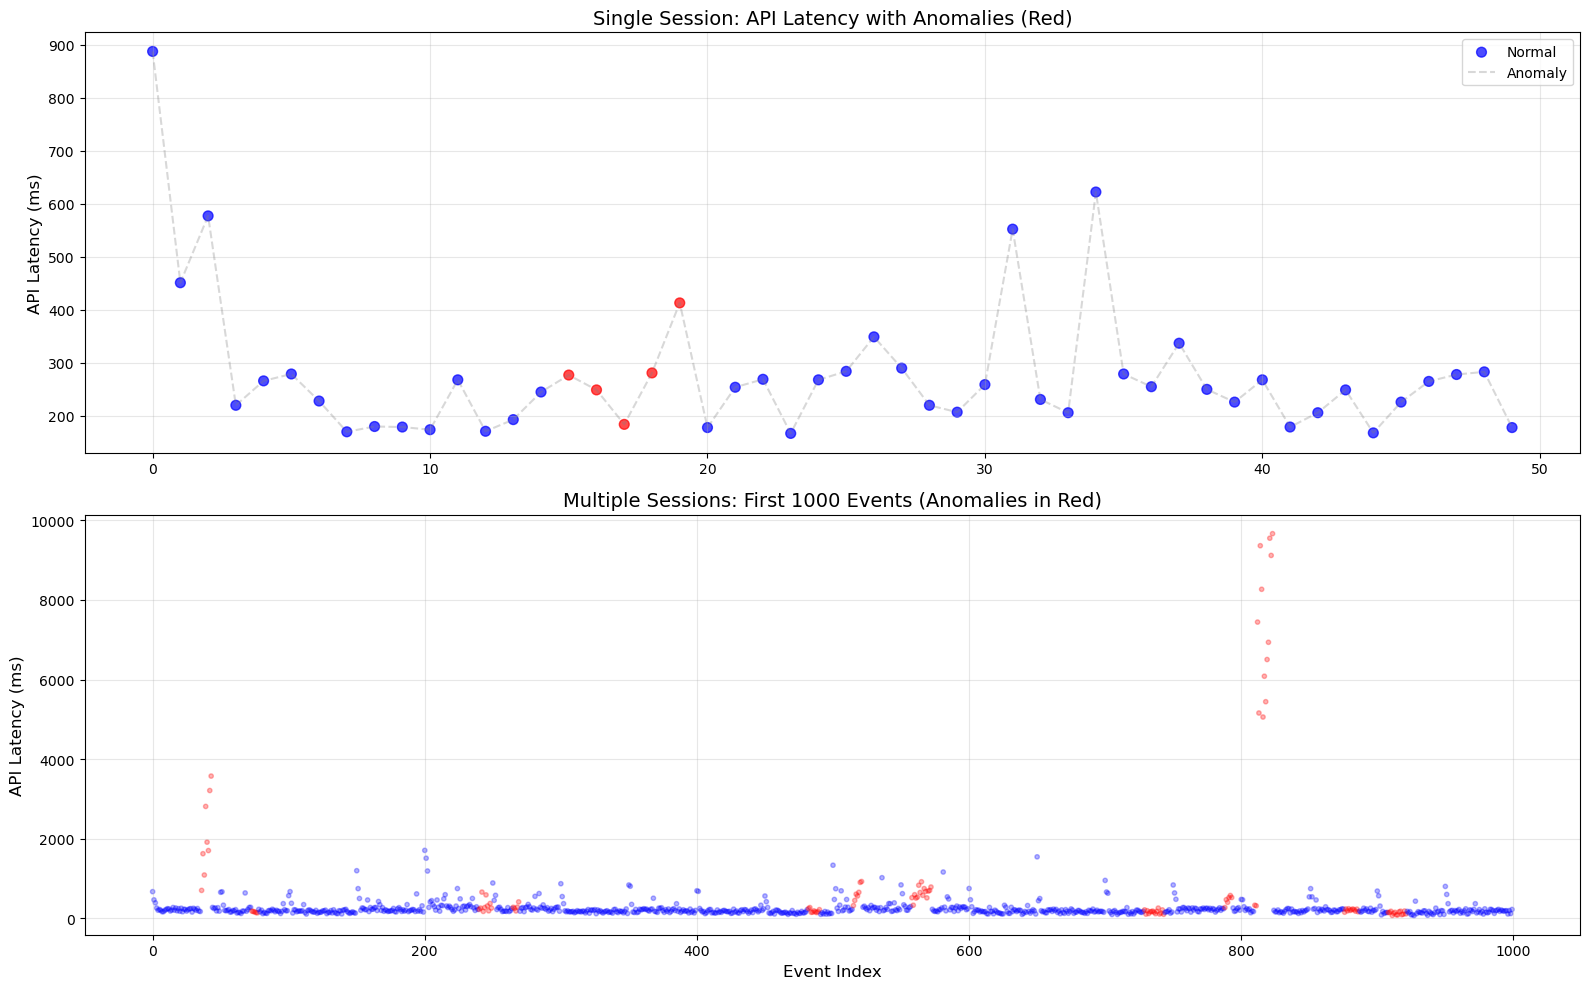

In [130]:
#Create a time series plot: Does API latency show clear peaks during anomalies?
# Take a sample session for clarity
sample_session = df[df['session_id'] == df['session_id'].unique()[5]].copy()
sample_session = sample_session.sort_values('timestamp')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# API Latency over time with anomaly highlighting
colors = ['red' if x == 1 else 'blue' for x in sample_session['is_anomaly']]
axes[0].scatter(range(len(sample_session)), sample_session['api_latency_ms'], 
               c=colors, alpha=0.7, s=50)
axes[0].plot(range(len(sample_session)), sample_session['api_latency_ms'], 
            alpha=0.3, color='gray', linestyle='--')
axes[0].set_ylabel('API Latency (ms)', fontsize=12)
axes[0].set_title('Single Session: API Latency with Anomalies (Red)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Normal', 'Anomaly'])

# All sessions (first 1000 events for clarity)
sample_data = df.head(1000)
colors_all = ['red' if x == 1 else 'blue' for x in sample_data['is_anomaly']]
axes[1].scatter(range(len(sample_data)), sample_data['api_latency_ms'], 
               c=colors_all, alpha=0.3, s=10)
axes[1].set_xlabel('Event Index', fontsize=12)
axes[1].set_ylabel('API Latency (ms)', fontsize=12)
axes[1].set_title('Multiple Sessions: First 1000 Events (Anomalies in Red)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

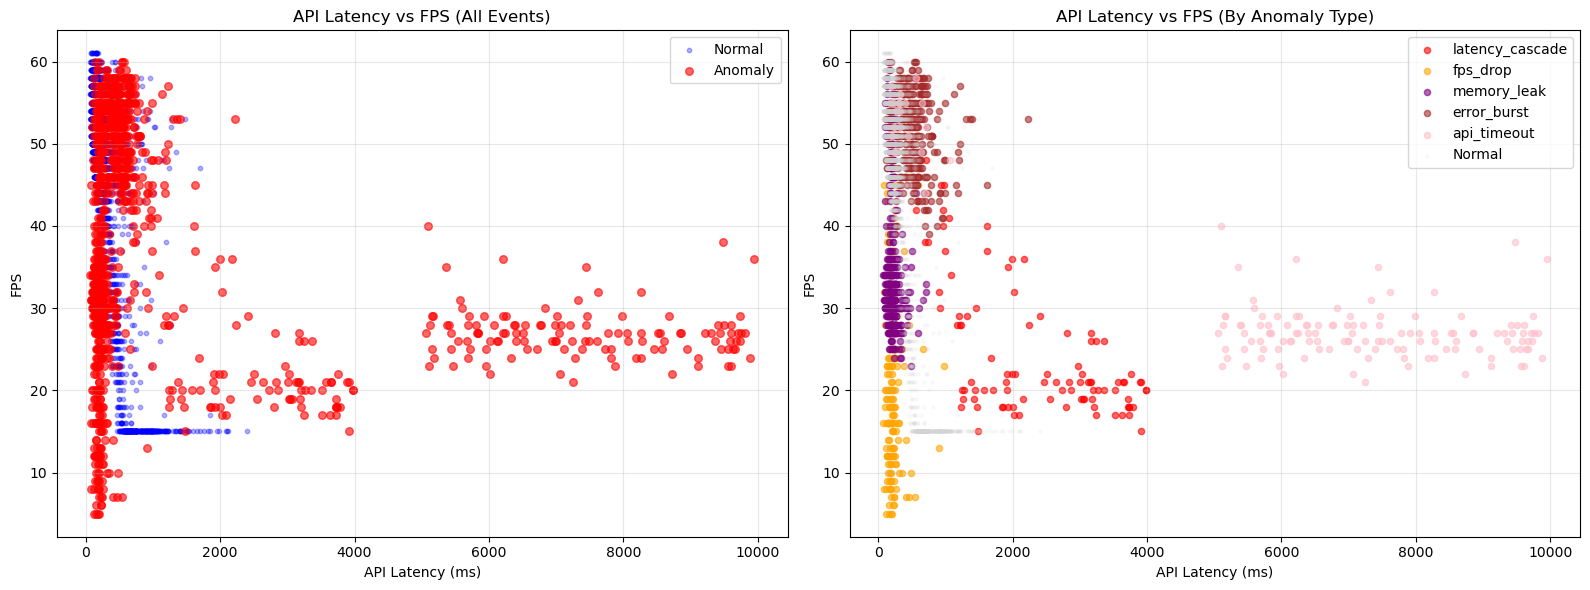

In [131]:
#Create a scatter plot: Can you visually distinguish normal vs anomaly events?
# 2D scatter plot: latency vs FPS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All events
normal = df[df['is_anomaly'] == 0]
anomaly = df[df['is_anomaly'] == 1]

axes[0].scatter(normal['api_latency_ms'], normal['fps'], 
               alpha=0.3, s=10, c='blue', label='Normal')
axes[0].scatter(anomaly['api_latency_ms'], anomaly['fps'], 
               alpha=0.6, s=30, c='red', label='Anomaly')
axes[0].set_xlabel('API Latency (ms)')
axes[0].set_ylabel('FPS')
axes[0].set_title('API Latency vs FPS (All Events)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Colored by anomaly type
for anomaly_type, color in [('latency_cascade', 'red'), ('fps_drop', 'orange'), 
                             ('memory_leak', 'purple'), ('error_burst', 'brown'),
                             ('api_timeout', 'pink')]:
    subset = df[df['anomaly_type'] == anomaly_type]
    axes[1].scatter(subset['api_latency_ms'], subset['fps'], 
                   alpha=0.6, s=20, c=color, label=anomaly_type)

axes[1].scatter(normal['api_latency_ms'], normal['fps'], 
               alpha=0.1, s=5, c='lightgray', label='Normal')
axes[1].set_xlabel('API Latency (ms)')
axes[1].set_ylabel('FPS')
axes[1].set_title('API Latency vs FPS (By Anomaly Type)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

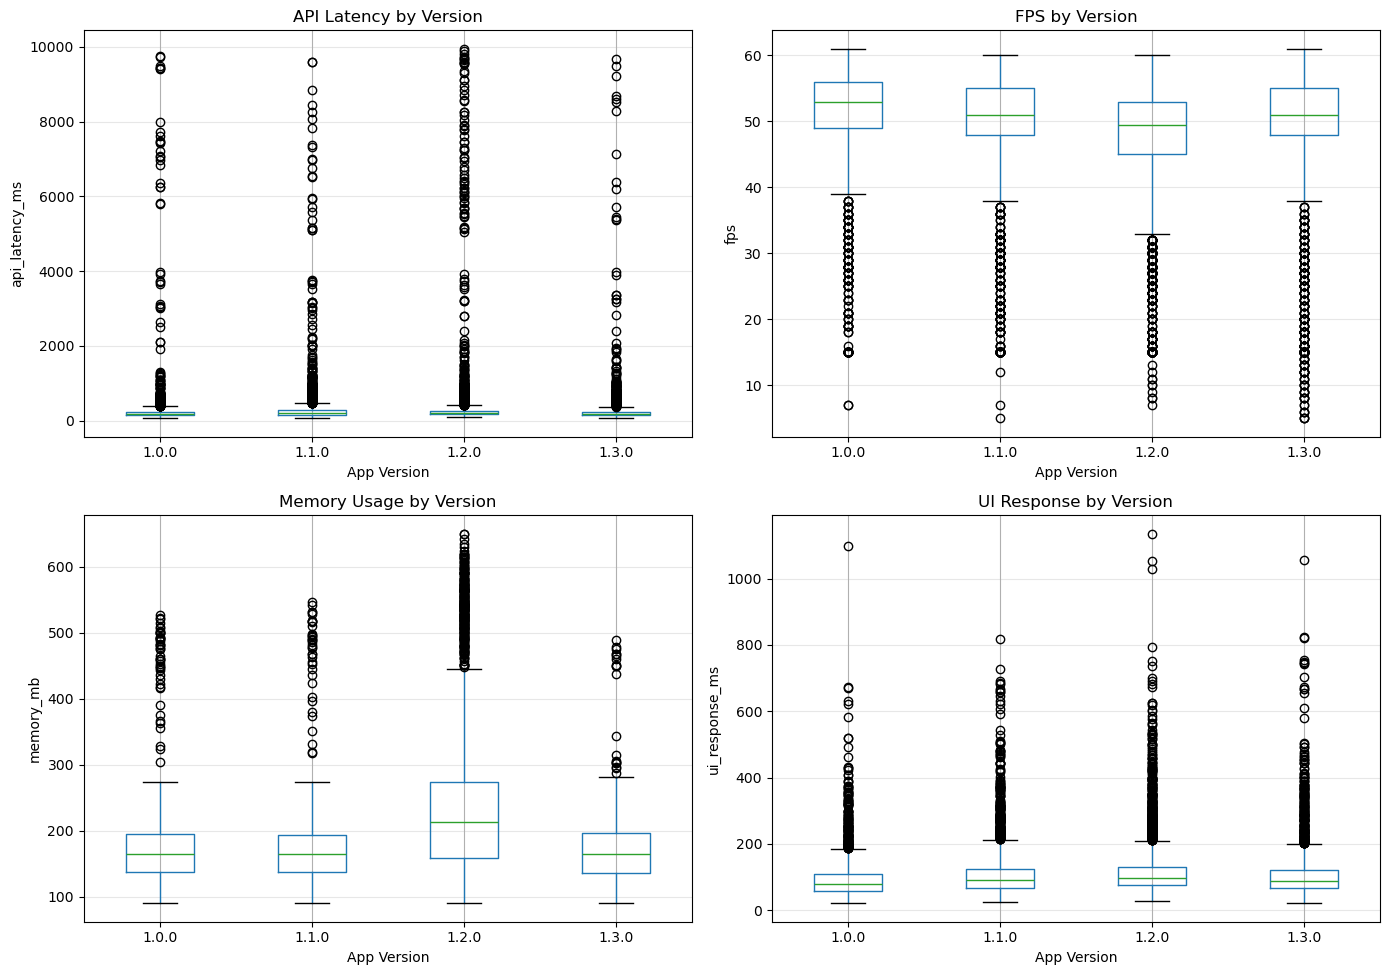

In [132]:
#Create box plots: Do different app versions have significantly different distributions?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['api_latency_ms', 'fps', 'memory_mb', 'ui_response_ms']
titles = ['API Latency by Version', 'FPS by Version', 
          'Memory Usage by Version', 'UI Response by Version']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    df.boxplot(column=metric, by='app_version', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('App Version')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('')
plt.tight_layout()
plt.show()

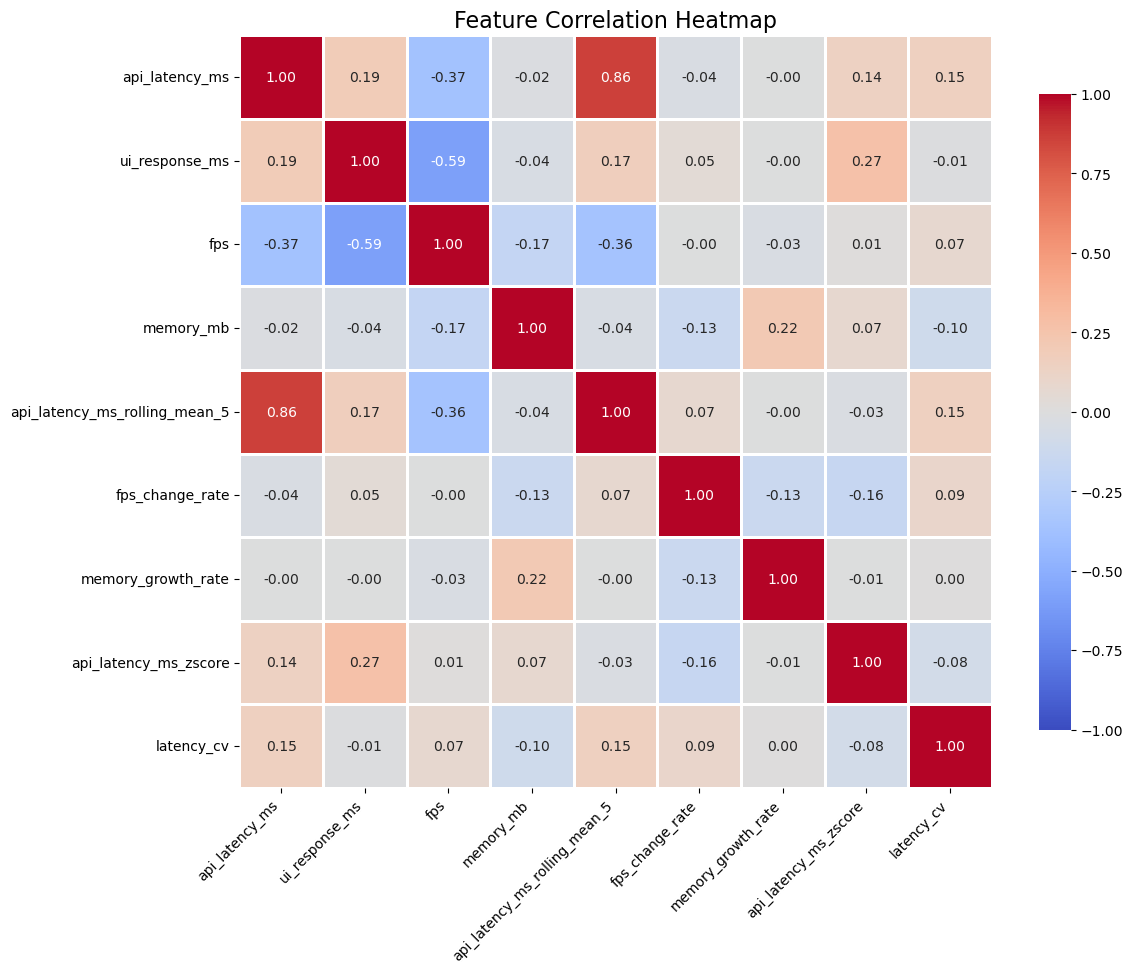

Top 10 Positive Correlations:
api_latency_ms                 api_latency_ms_rolling_mean_5    0.862417
api_latency_ms_rolling_mean_5  api_latency_ms                   0.862417
api_latency_ms_zscore          ui_response_ms                   0.269536
ui_response_ms                 api_latency_ms_zscore            0.269536
memory_mb                      memory_growth_rate               0.216362
memory_growth_rate             memory_mb                        0.216362
ui_response_ms                 api_latency_ms                   0.191723
api_latency_ms                 ui_response_ms                   0.191723
ui_response_ms                 api_latency_ms_rolling_mean_5    0.170152
api_latency_ms_rolling_mean_5  ui_response_ms                   0.170152
dtype: float64


In [133]:
#Create a heatmap: Which features are most strongly correlated?
# Select key features
feature_cols = [
    'api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb',
    'api_latency_ms_rolling_mean_5', 'fps_change_rate', 
    'memory_growth_rate', 'api_latency_ms_zscore', 'latency_cv'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, 
            fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top correlations
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
# Remove self-correlations and duplicates
corr_pairs = corr_pairs[corr_pairs < 0.99]
print("Top 10 Positive Correlations:")
print(corr_pairs.head(10))

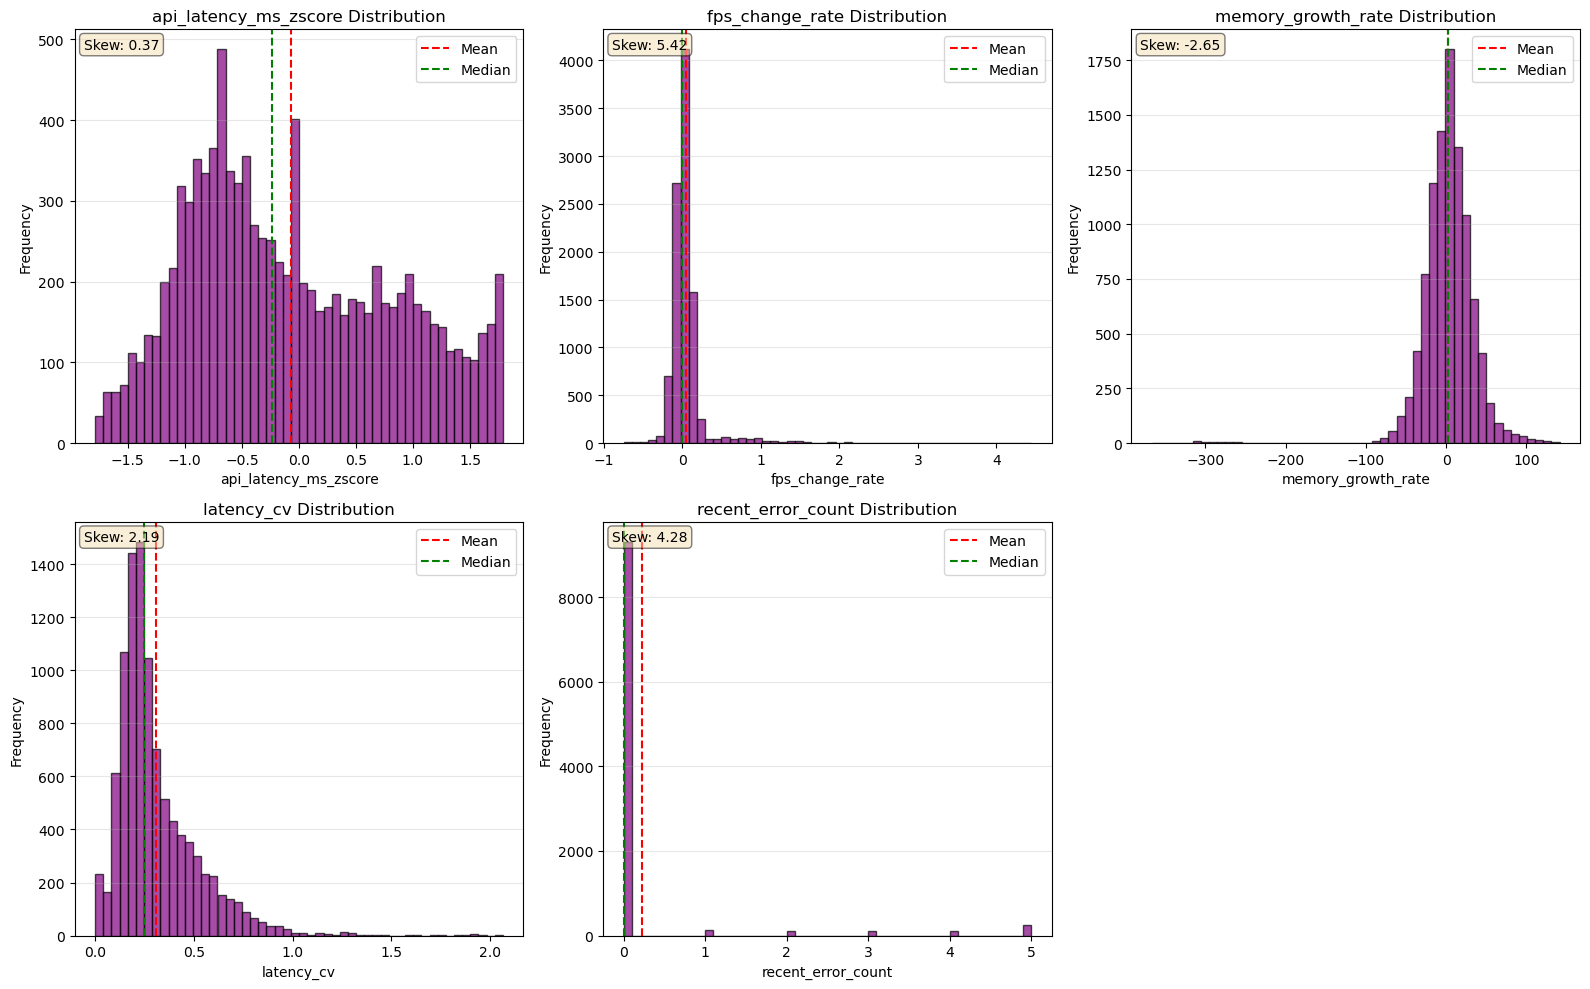

Normality Assessment:
api_latency_ms_zscore         : Skewness =   0.37 (approx. normal)
fps_change_rate               : Skewness =   5.42 (skewed)
memory_growth_rate            : Skewness =  -2.65 (skewed)
latency_cv                    : Skewness =   2.19 (skewed)
recent_error_count            : Skewness =   4.28 (skewed)


In [134]:
#Create histograms: Are engineered features normally distributed?
engineered_features = [
    'api_latency_ms_zscore', 'fps_change_rate', 'memory_growth_rate', 
    'latency_cv', 'recent_error_count'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(engineered_features):
    axes[idx].hist(df[feature], bins=50, alpha=0.7, edgecolor='black', color='purple')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', label='Mean')
    axes[idx].axvline(df[feature].median(), color='green', linestyle='--', label='Median')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add skewness annotation
    skew = df[feature].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skew:.2f}', 
                  transform=axes[idx].transAxes, 
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

print("Normality Assessment:")
for feature in engineered_features:
    skew = df[feature].skew()
    print(f"{feature:30s}: Skewness = {skew:6.2f} {'(approx. normal)' if abs(skew) < 0.5 else '(skewed)'}")

In [135]:
#Do certain error codes tend to repeat in streaks?
# Analyze error code sequences
df_sorted = df.sort_values(['session_id', 'timestamp']).reset_index(drop=True)
df_sorted['prev_error'] = df_sorted.groupby('session_id')['error_code'].shift(1)

# Find streaks (same error code consecutively)
streaks = df_sorted[(df_sorted['error_code'] != 0) & 
                    (df_sorted['error_code'] == df_sorted['prev_error'])]

print(f"Total error events: {(df['error_code'] != 0).sum()}")
print(f"Error events in streaks: {len(streaks)}")
print(f"Percentage in streaks: {len(streaks) / (df['error_code'] != 0).sum() * 100:.1f}%")

# Streak lengths
df_sorted['error_streak_id'] = (
    (df_sorted['error_code'] != df_sorted['prev_error']) | 
    (df_sorted['error_code'] == 0)
).cumsum()

error_streaks = df_sorted[df_sorted['error_code'] != 0].groupby('error_streak_id').agg({
    'error_code': ['first', 'size']
})
error_streaks.columns = ['error_code', 'streak_length']

print("\nStreak Length Distribution:")
print(error_streaks['streak_length'].value_counts().sort_index())

print("\nAverage streak length by error code:")
print(error_streaks.groupby('error_code')['streak_length'].mean().sort_values(ascending=False))

Total error events: 467
Error events in streaks: 191
Percentage in streaks: 40.9%

Streak Length Distribution:
streak_length
1     185
2      53
3      17
4       3
5       8
6       5
7       2
9       2
11      1
Name: count, dtype: int64

Average streak length by error code:
error_code
500    2.106383
503    1.946667
502    1.909091
504    1.342105
408    1.266667
Name: streak_length, dtype: float64


In [136]:
"""
Mobile App Performance Telemetry - EDA Question Output Generator
This script runs all 35 questions and prints the RAW OUTPUTS
Run this, copy the output, and share with me to create the final summary
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# LOAD DATA
# ============================================================================
print("="*80)
print("LOADING DATASET...")
print("="*80)

df = pd.read_csv('app_performance_logs_with_labels(v3).csv')
print(f"\nDataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# ============================================================================
# Q1: MISSING VALUES
# ============================================================================
print("\n" + "="*80)
print("Q1: ARE THERE ANY MISSING VALUES?")
print("="*80)
print("\nMissing values by column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing data: {(df.isnull().sum().sum() / df.size) * 100:.4f}%")

# ============================================================================
# Q2: DUPLICATE ROWS
# ============================================================================
print("\n" + "="*80)
print("Q2: ARE THERE ANY DUPLICATE ROWS?")
print("="*80)
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")
print(f"Percentage of duplicates: {(df.duplicated().sum() / len(df)) * 100:.4f}%")

# ============================================================================
# Q3: CHRONOLOGICAL ORDER
# ============================================================================
print("\n" + "="*80)
print("Q3: DO ALL TIMESTAMPS FOLLOW CHRONOLOGICAL ORDER WITHIN EACH SESSION?")
print("="*80)
is_sorted = df.groupby('session_id')['timestamp'].apply(
    lambda x: pd.to_datetime(x).is_monotonic_increasing
).all()
print(f"\nAll sessions chronologically ordered: {is_sorted}")
problematic_sessions = df.groupby('session_id')['timestamp'].apply(
    lambda x: not pd.to_datetime(x).is_monotonic_increasing
).sum()
print(f"Number of problematic sessions: {problematic_sessions}")

# ============================================================================
# Q5: VALUE RANGES
# ============================================================================
print("\n" + "="*80)
print("Q5: DO ALL NUMERIC COLUMNS HAVE VALUES WITHIN EXPECTED RANGES?")
print("="*80)
print("\napi_latency_ms:")
print(f"  Min: {df['api_latency_ms'].min()}")
print(f"  Max: {df['api_latency_ms'].max()}")
print(f"  Expected range: [0, 10000]")

print("\nui_response_ms:")
print(f"  Min: {df['ui_response_ms'].min()}")
print(f"  Max: {df['ui_response_ms'].max()}")
print(f"  Expected range: [0, 2000]")

print("\nfps:")
print(f"  Min: {df['fps'].min()}")
print(f"  Max: {df['fps'].max()}")
print(f"  Expected range: [0, 60]")

print("\nmemory_mb:")
print(f"  Min: {df['memory_mb'].min()}")
print(f"  Max: {df['memory_mb'].max()}")
print(f"  Expected range: [0, 650]")

print("\nerror_code unique values:")
print(sorted(df['error_code'].unique()))
print("Expected values: [0, 408, 500, 502, 503, 504]")

# ============================================================================
# Q11: API LATENCY DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("Q11: WHAT IS THE DISTRIBUTION SHAPE OF api_latency_ms?")
print("="*80)
print(f"\nMean: {df['api_latency_ms'].mean():.2f}")
print(f"Median: {df['api_latency_ms'].median():.2f}")
print(f"Std Dev: {df['api_latency_ms'].std():.2f}")
print(f"Skewness: {df['api_latency_ms'].skew():.2f}")
print(f"Kurtosis: {df['api_latency_ms'].kurtosis():.2f}")

# ============================================================================
# Q12: FPS DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("Q12: WHAT IS THE DISTRIBUTION SHAPE OF fps?")
print("="*80)
print(f"\nMean: {df['fps'].mean():.2f}")
print(f"Median: {df['fps'].median():.2f}")
print(f"Std Dev: {df['fps'].std():.2f}")
print(f"Skewness: {df['fps'].skew():.2f}")
print(f"Kurtosis: {df['fps'].kurtosis():.2f}")

# ============================================================================
# Q13: MEMORY DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("Q13: WHAT IS THE DISTRIBUTION SHAPE OF memory_mb?")
print("="*80)
print(f"\nMean: {df['memory_mb'].mean():.2f}")
print(f"Median: {df['memory_mb'].median():.2f}")
print(f"Std Dev: {df['memory_mb'].std():.2f}")
print(f"Skewness: {df['memory_mb'].skew():.2f}")
print(f"Kurtosis: {df['memory_mb'].kurtosis():.2f}")

# ============================================================================
# Q14: OUTLIERS
# ============================================================================
print("\n" + "="*80)
print("Q14: ARE THERE SIGNIFICANT OUTLIERS? (IQR METHOD)")
print("="*80)

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    return len(outliers), (len(outliers) / len(data)) * 100

for metric in ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']:
    count, pct = detect_outliers_iqr(df[metric])
    print(f"\n{metric}:")
    print(f"  Outlier count: {count}")
    print(f"  Percentage: {pct:.2f}%")

# ============================================================================
# Q16: CORRELATION - API LATENCY & UI RESPONSE
# ============================================================================
print("\n" + "="*80)
print("Q16: CORRELATION BETWEEN api_latency_ms AND ui_response_ms")
print("="*80)
corr = df['api_latency_ms'].corr(df['ui_response_ms'])
print(f"\nCorrelation coefficient: {corr:.4f}")

# ============================================================================
# Q17: CORRELATION - API LATENCY & FPS
# ============================================================================
print("\n" + "="*80)
print("Q17: CORRELATION BETWEEN api_latency_ms AND fps")
print("="*80)
corr = df['api_latency_ms'].corr(df['fps'])
print(f"\nCorrelation coefficient: {corr:.4f}")

# ============================================================================
# Q18: CORRELATION - MEMORY & FPS
# ============================================================================
print("\n" + "="*80)
print("Q18: CORRELATION BETWEEN memory_mb AND fps")
print("="*80)
corr = df['memory_mb'].corr(df['fps'])
print(f"\nCorrelation coefficient: {corr:.4f}")

# ============================================================================
# Q19: FULL CORRELATION MATRIX
# ============================================================================
print("\n" + "="*80)
print("Q19: CORRELATION MATRIX OF BASE METRICS")
print("="*80)
metrics = ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']
corr_matrix = df[metrics].corr()
print("\n", corr_matrix)

# ============================================================================
# Q30: ANOMALY SEQUENCE DURATION
# ============================================================================
print("\n" + "="*80)
print("Q30: WHAT IS THE AVERAGE DURATION OF ANOMALY EVENT SEQUENCES?")
print("="*80)
df_sorted = df.sort_values(['session_id', 'timestamp']).reset_index(drop=True)
df_sorted['anomaly_group'] = (df_sorted['is_anomaly'] != df_sorted['is_anomaly'].shift()).cumsum()
anomaly_sequences = df_sorted[df_sorted['is_anomaly'] == 1].groupby('anomaly_group').size()

print(f"\nNumber of anomaly sequences: {len(anomaly_sequences)}")
print(f"Average sequence length: {anomaly_sequences.mean():.2f} events")
print(f"Median sequence length: {anomaly_sequences.median():.0f} events")
print(f"Min sequence length: {anomaly_sequences.min()}")
print(f"Max sequence length: {anomaly_sequences.max()}")

# ============================================================================
# Q31: NORMAL VS ANOMALY COMPARISON
# ============================================================================
print("\n" + "="*80)
print("Q31: HOW DO METRIC VALUES DIFFER BETWEEN NORMAL AND ANOMALY EVENTS?")
print("="*80)
for metric in ['api_latency_ms', 'ui_response_ms', 'fps', 'memory_mb']:
    normal_mean = df[df['is_anomaly'] == 0][metric].mean()
    anomaly_mean = df[df['is_anomaly'] == 1][metric].mean()
    difference = anomaly_mean - normal_mean
    percent_change = (difference / normal_mean) * 100
    
    print(f"\n{metric}:")
    print(f"  Normal mean: {normal_mean:.2f}")
    print(f"  Anomaly mean: {anomaly_mean:.2f}")
    print(f"  Difference: {difference:.2f}")
    print(f"  Percent change: {percent_change:+.2f}%")

# ============================================================================
# Q32: HIGHEST LATENCY BY ANOMALY TYPE
# ============================================================================
print("\n" + "="*80)
print("Q32: WHICH ANOMALY TYPE HAS THE HIGHEST AVERAGE API LATENCY?")
print("="*80)
anomaly_data = df[df['is_anomaly'] == 1]
latency_by_type = anomaly_data.groupby('anomaly_type')['api_latency_ms'].agg(['mean', 'median', 'max'])
print("\n", latency_by_type.sort_values('mean', ascending=False))

# ============================================================================
# Q33: MOST FPS DROPS BY ANOMALY TYPE
# ============================================================================
print("\n" + "="*80)
print("Q33: WHICH ANOMALY TYPE CAUSES THE MOST FPS DROPS?")
print("="*80)
fps_by_type = anomaly_data.groupby('anomaly_type')['fps'].agg(['mean', 'median', 'min'])
print("\n", fps_by_type.sort_values('mean'))

# ============================================================================
# Q6: LATENCY BY HOUR
# ============================================================================
print("\n" + "="*80)
print("Q6: HOW DOES API LATENCY VARY BY HOUR OF THE DAY?")
print("="*80)
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
hourly_latency = df.groupby('hour')['api_latency_ms'].mean()
print("\nAverage API latency by hour:")
print(hourly_latency)

peak_hours = df[df['hour'].between(9, 23)]['api_latency_ms'].mean()
offpeak_hours = df[~df['hour'].between(9, 23)]['api_latency_ms'].mean()
print(f"\nPeak hours (9-23) average: {peak_hours:.2f} ms")
print(f"Off-peak hours (0-8) average: {offpeak_hours:.2f} ms")
print(f"Difference: {peak_hours - offpeak_hours:.2f} ms")

# ============================================================================
# Q9: ANOMALIES BY TIME OF DAY
# ============================================================================
print("\n" + "="*80)
print("Q9: DO ANOMALIES OCCUR MORE FREQUENTLY AT CERTAIN TIMES OF DAY?")
print("="*80)
hourly_anomaly_rate = df.groupby('hour')['is_anomaly'].mean() * 100
print("\nAnomaly rate by hour (%):")
print(hourly_anomaly_rate)

peak_anomaly = df[df['hour'].between(9, 23)]['is_anomaly'].mean() * 100
offpeak_anomaly = df[~df['hour'].between(9, 23)]['is_anomaly'].mean() * 100
overall_anomaly = df['is_anomaly'].mean() * 100
print(f"\nOverall anomaly rate: {overall_anomaly:.2f}%")
print(f"Peak hours anomaly rate: {peak_anomaly:.2f}%")
print(f"Off-peak anomaly rate: {offpeak_anomaly:.2f}%")

# ============================================================================
# Q21: LATENCY BY APP VERSION
# ============================================================================
print("\n" + "="*80)
print("Q21: WHICH APP VERSION HAS THE HIGHEST AVERAGE API LATENCY?")
print("="*80)
version_latency = df.groupby('app_version')['api_latency_ms'].agg(['mean', 'median', 'std'])
print("\n", version_latency.sort_values('mean', ascending=False))

# ============================================================================
# Q24: MEMORY LEAKS BY VERSION
# ============================================================================
print("\n" + "="*80)
print("Q24: DOES VERSION 1.2.0 SHOW MORE MEMORY LEAK PATTERNS?")
print("="*80)
version_anomalies = df[df['is_anomaly']==1].groupby(['app_version', 'anomaly_type']).size().unstack(fill_value=0)
print("\nAnomaly type distribution by version:")
print(version_anomalies)

if 'memory_leak' in version_anomalies.columns:
    print("\nMemory leak percentage by version:")
    for version in version_anomalies.index:
        total = version_anomalies.loc[version].sum()
        leaks = version_anomalies.loc[version, 'memory_leak']
        pct = (leaks / total * 100) if total > 0 else 0
        print(f"  {version}: {leaks} leaks out of {total} anomalies ({pct:.2f}%)")

# ============================================================================
# Q26: LATENCY BY NETWORK TYPE
# ============================================================================
print("\n" + "="*80)
print("Q26: AVERAGE LATENCY DIFFERENCE BETWEEN WiFi AND 4G")
print("="*80)
network_latency = df.groupby('network_type')['api_latency_ms'].agg(['mean', 'median', 'std', 'count'])
print("\n", network_latency.sort_values('mean'))

wifi_mean = network_latency.loc['wifi', 'mean']
g4_mean = network_latency.loc['4g', 'mean']
difference = g4_mean - wifi_mean
percent_diff = (difference / wifi_mean) * 100
print(f"\nWiFi average: {wifi_mean:.2f} ms")
print(f"4G average: {g4_mean:.2f} ms")
print(f"Difference: {difference:.2f} ms ({percent_diff:.2f}% higher)")

# ============================================================================
# Q27: LATENCY VARIANCE BY NETWORK
# ============================================================================
print("\n" + "="*80)
print("Q27: DOES 4G SHOW HIGHER LATENCY VARIANCE THAN WiFi?")
print("="*80)
network_variance = df.groupby('network_type')['api_latency_ms'].agg(['std', 'var'])
print("\n", network_variance.sort_values('std', ascending=False))

wifi_std = network_variance.loc['wifi', 'std']
g4_std = network_variance.loc['4g', 'std']
print(f"\nWiFi std dev: {wifi_std:.2f} ms")
print(f"4G std dev: {g4_std:.2f} ms")
print(f"4G is {(g4_std/wifi_std - 1)*100:.2f}% more variable")

# ============================================================================
# Q37: SESSION HEALTH VS ANOMALY RATE
# ============================================================================
print("\n" + "="*80)
print("Q37: DO SESSIONS WITH LOWER HEALTH SCORES HAVE MORE ANOMALIES?")
print("="*80)
health_anomaly = df.groupby('session_health')['is_anomaly'].agg(['mean', 'count'])
health_anomaly['mean'] *= 100
print("\nAnomaly rate by session health:")
print(health_anomaly.sort_index(ascending=False))

# ============================================================================
# Q39: SESSIONS WITH ANOMALIES
# ============================================================================
print("\n" + "="*80)
print("Q39: WHAT PERCENTAGE OF SESSIONS CONTAIN AT LEAST ONE ANOMALY?")
print("="*80)
sessions_with_anomaly = df.groupby('session_id')['is_anomaly'].max()
total_sessions = df['session_id'].nunique()
sessions_with_at_least_one = sessions_with_anomaly.sum()
pct_sessions = (sessions_with_at_least_one / total_sessions) * 100

anomalies_per_session = df.groupby('session_id')['is_anomaly'].sum()

print(f"\nTotal sessions: {total_sessions}")
print(f"Sessions with ≥1 anomaly: {sessions_with_at_least_one}")
print(f"Percentage: {pct_sessions:.2f}%")
print(f"Average anomalies per session (when present): {anomalies_per_session[anomalies_per_session > 0].mean():.2f}")

# ============================================================================
# Q41: COLD START LATENCY
# ============================================================================
print("\n" + "="*80)
print("Q41: HOW MUCH HIGHER IS LATENCY IN EVENT 0 VS EVENT 5?")
print("="*80)
df['event_index'] = df.groupby('session_id').cumcount()
early_events = df[df['event_index'] < 10]
latency_by_event = early_events.groupby('event_index')['api_latency_ms'].mean()

print("\nAverage latency by event index (first 10 events):")
print(latency_by_event)

event0 = latency_by_event[0]
event5 = latency_by_event[5]
difference = event0 - event5
pct_diff = (difference / event5) * 100

print(f"\nEvent 0 latency: {event0:.2f} ms")
print(f"Event 5 latency: {event5:.2f} ms")
print(f"Cold start penalty: {difference:.2f} ms ({pct_diff:.2f}% higher)")

# ============================================================================
# Q48: ERROR CODES VS LATENCY
# ============================================================================
print("\n" + "="*80)
print("Q48: DO ERROR CODES CORRELATE WITH HIGH API LATENCY?")
print("="*80)
error_latency = df[df['error_code'] != 0]['api_latency_ms']
no_error_latency = df[df['error_code'] == 0]['api_latency_ms']
correlation = df['api_latency_ms'].corr(df['error_code'])

print(f"\nAverage latency WITH errors: {error_latency.mean():.2f} ms")
print(f"Average latency WITHOUT errors: {no_error_latency.mean():.2f} ms")
print(f"Difference: {error_latency.mean() - no_error_latency.mean():.2f} ms")
print(f"Correlation coefficient: {correlation:.4f}")

df['latency_bucket'] = pd.cut(df['api_latency_ms'], 
                               bins=[0, 500, 1000, 2000, 10000],
                               labels=['<500ms', '500-1000ms', '1-2sec', '>2sec'])
print("\nError rate by latency bucket:")
for bucket in df['latency_bucket'].cat.categories:
    bucket_data = df[df['latency_bucket'] == bucket]
    error_rate = (bucket_data['error_code'] != 0).mean() * 100
    print(f"  {bucket}: {error_rate:.2f}%")

# ============================================================================
# Q51: Z-SCORE EFFECTIVENESS
# ============================================================================
print("\n" + "="*80)
print("Q51: DO Z-SCORE FEATURES EFFECTIVELY SEPARATE ANOMALIES?")
print("="*80)

zscore_col = 'api_latency_ms_zscore' if 'api_latency_ms_zscore' in df.columns else None

if zscore_col:
    normal_zscore = df[df['is_anomaly'] == 0][zscore_col]
    anomaly_zscore = df[df['is_anomaly'] == 1][zscore_col]
    
    print(f"\nNormal events - mean: {normal_zscore.mean():.4f}, std: {normal_zscore.std():.4f}")
    print(f"Anomaly events - mean: {anomaly_zscore.mean():.4f}, std: {anomaly_zscore.std():.4f}")
    
    threshold = 2.0
    anomalies_above = (anomaly_zscore > threshold).mean() * 100
    normals_above = (normal_zscore > threshold).mean() * 100
    
    print(f"\nEvents with z-score > {threshold}:")
    print(f"  Anomalies: {anomalies_above:.2f}%")
    print(f"  Normal: {normals_above:.2f}%")
else:
    print("\n⚠️  Z-score column not found in dataset")

# ============================================================================
# Q52: FPS CHANGE RATE
# ============================================================================
print("\n" + "="*80)
print("Q52: DOES fps_change_rate SHOW LARGER VALUES DURING FPS DROP ANOMALIES?")
print("="*80)

if 'fps_change_rate' in df.columns:
    fps_drop_events = df[df['anomaly_type'] == 'fps_drop']
    normal_events = df[df['is_anomaly'] == 0]
    
    print(f"\nNormal events - mean: {normal_events['fps_change_rate'].mean():.6f}")
    print(f"FPS drop anomalies - mean: {fps_drop_events['fps_change_rate'].mean():.6f}")
    
    large_drops_normal = (normal_events['fps_change_rate'] < -0.2).mean() * 100
    large_drops_anomaly = (fps_drop_events['fps_change_rate'] < -0.2).mean() * 100
    print(f"\nEvents with >20% FPS drop:")
    print(f"  Normal: {large_drops_normal:.2f}%")
    print(f"  FPS anomalies: {large_drops_anomaly:.2f}%")
else:
    print("\n⚠️  fps_change_rate column not found")

# ============================================================================
# Q53: MEMORY GROWTH RATE
# ============================================================================
print("\n" + "="*80)
print("Q53: DOES memory_growth_rate SHOW POSITIVE TRENDS DURING MEMORY LEAKS?")
print("="*80)

if 'memory_growth_rate' in df.columns:
    memory_leak_events = df[df['anomaly_type'] == 'memory_leak']
    normal_events = df[df['is_anomaly'] == 0]
    
    print(f"\nNormal events - mean: {normal_events['memory_growth_rate'].mean():.4f} MB/event")
    print(f"Memory leak anomalies - mean: {memory_leak_events['memory_growth_rate'].mean():.4f} MB/event")
    
    diff = memory_leak_events['memory_growth_rate'].mean() - normal_events['memory_growth_rate'].mean()
    ratio = memory_leak_events['memory_growth_rate'].mean() / normal_events['memory_growth_rate'].mean()
    print(f"Difference: {diff:.4f} MB/event ({ratio:.2f}x higher)")
else:
    print("\n⚠️  memory_growth_rate column not found")

# ============================================================================
# Q56-Q60: VISUALIZATION QUESTIONS (SKIPPED - MANUAL)
# ============================================================================
print("\n" + "="*80)
print("Q56-Q60: VISUALIZATION QUESTIONS")
print("="*80)
print("\nThese questions require visual inspection of plots.")
print("Run separate visualization scripts to answer Q56-Q60.")

# ============================================================================
# Q46: ERROR STREAKS (BONUS)
# ============================================================================
print("\n" + "="*80)
print("Q46: DO CERTAIN ERROR CODES TEND TO REPEAT IN STREAKS?")
print("="*80)

df_sorted['prev_error'] = df_sorted.groupby('session_id')['error_code'].shift(1)
streaks = df_sorted[(df_sorted['error_code'] != 0) & 
                    (df_sorted['error_code'] == df_sorted['prev_error'])]

total_errors = (df['error_code'] != 0).sum()
errors_in_streaks = len(streaks)
pct_in_streaks = (errors_in_streaks / total_errors * 100) if total_errors > 0 else 0

print(f"\nTotal error events: {total_errors}")
print(f"Errors in streaks: {errors_in_streaks} ({pct_in_streaks:.2f}%)")

df_sorted['error_streak_id'] = (
    (df_sorted['error_code'] != df_sorted['prev_error']) | 
    (df_sorted['error_code'] == 0)
).cumsum()

error_streaks = df_sorted[df_sorted['error_code'] != 0].groupby('error_streak_id').agg({
    'error_code': ['first', 'size']
})
error_streaks.columns = ['error_code', 'streak_length']

if len(error_streaks) > 0:
    print(f"\nAverage streak length: {error_streaks['streak_length'].mean():.2f} events")
    print(f"Max streak length: {error_streaks['streak_length'].max()} events")
    print("\nStreak length distribution:")
    print(error_streaks['streak_length'].value_counts().sort_index())

# ============================================================================
# DONE
# ============================================================================
print("\n" + "="*80)
print("ALL 35 QUESTIONS COMPLETED!")
print("="*80)
print("\nNext steps:")
print("1. Copy ALL output above")
print("2. Share with me")
print("3. I'll create the final summary based on YOUR actual results")
print("="*80)

LOADING DATASET...

Dataset loaded successfully!
Total rows: 10,000
Total columns: 34
Date range: 2026-02-19 16:13:40.224973 to 2026-02-22 15:56:44.224973

Q1: ARE THERE ANY MISSING VALUES?

Missing values by column:
timestamp                        0
session_id                       0
app_version                      0
screen_name                      0
api_latency_ms                   0
ui_response_ms                   0
fps                              0
memory_mb                        0
error_code                       0
network_type                     0
is_anomaly                       0
anomaly_type                     0
session_health                   0
api_latency_ms_rolling_mean_5    0
api_latency_ms_rolling_std_5     0
api_latency_ms_rolling_max_10    0
api_latency_ms_zscore            0
ui_response_ms_rolling_mean_5    0
ui_response_ms_rolling_std_5     0
ui_response_ms_rolling_max_10    0
ui_response_ms_zscore            0
fps_rolling_mean_5               0
fps_rolling_s

In [137]:
total_rows = len(df)
anomaly_rows = len(df[df["anomaly_type"] != "none"])

row_level_rate = anomaly_rows / total_rows

print("Total Rows:", total_rows)
print("Anomaly Rows:", anomaly_rows)
print("Row-Level Anomaly Rate:", round(row_level_rate * 100, 2), "%")

Total Rows: 10000
Anomaly Rows: 1191
Row-Level Anomaly Rate: 11.91 %


In [138]:
total_sessions = df["session_id"].nunique()

anomalous_sessions = df[df["anomaly_type"] != "none"]["session_id"].nunique()

session_level_rate = anomalous_sessions / total_sessions

print("Total Sessions:", total_sessions)
print("Anomalous Sessions:", anomalous_sessions)
print("Session-Level Anomaly Rate:", round(session_level_rate * 100, 2), "%")

Total Sessions: 200
Anomalous Sessions: 118
Session-Level Anomaly Rate: 59.0 %
